# Importing packages

In [ ]:
# Imports
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from matplotlib.gridspec import GridSpec

import geopandas as gpd
import cartopy.io.shapereader as shpreader
import regionmask

import cartopy.crs as ccrs
import dask
from pathlib import Path
import sys
from importlib import reload

# Custom libraries
PROJECT_ROOT = Path.home() / 'KNMIproject'
sys.path.insert(0, str(PROJECT_ROOT))

from RegionalTrends.Helpers import ProcessVar
reload(ProcessVar)
from RegionalTrends.Helpers.ProcessVar import load_var

from RegionalTrends.Helpers import AreaWeights
reload(AreaWeights)
from RegionalTrends.Helpers.AreaWeights import area_weights, area_weighted_mean

import RegionalTrends.Helpers.Config.Constants as Constants
reload(Constants)

plt.rcParams['axes.unicode_minus'] = False
dask.config.set(scheduler='threads', num_workers=12)

## Data loading

In [20]:
# User inputs
tends_main = {'Total': 'tendtot'}
tends_close = {'Total': ['dyntot', 'phystot', 'numtot']}
t2m_datasets = ['RACMO2.4A', 'RACMO2.4R', 'ERA5', 'Eobs','Stations'] # Eobs en RACMO2.4!
stations = ['Bilt', 'Eelde', 'Kooy', 'Maastricht', 'Vlissingen']
years = [1960, 2024]
file_freq = 'Daily'

lats = [50.7, 53.6]
lons = [3.25, 7.35]
proj_sel = 'RACMO2.4'
land_only = True
trim_border = None
shapefile_NL = True

In [21]:
# Config setup
data_sources = Constants.DATA_SOURCES
station_sources = Constants.STATION_SOURCES
station_coord_cfg = Constants.STATION_COORD_CFG
var_file_cfg = Constants.VAR_FILE_CFG
proj_cfg = Constants.PROJ_CFG

build_file_cfg_base = ProcessVar.build_file_cfg

def build_file_cfg_A(freq_str):
    freq_suffix = {'Daily': 'dailyA', 'Monthly': 'monthlyA', 'Seasonal': 'seasonalA'}[freq_str]
    cfg = build_file_cfg_base(freq_str)
    for var in Constants.ENBUD_VARS:
        cfg['RACMO2.4A'][var] = f'/nobackup_1/users/walj/racmo24/{freq_str}/{var}_{freq_suffix}_KEXT12_RACMO24p1v7_FINAL_enbud_fix_*.nc'
    return cfg

ProcessVar.build_file_cfg = build_file_cfg_A

In [22]:
# Data loading
proj_sel = proj_cfg.get(proj_sel, ccrs.PlateCarree())
years_load = list(range(years[0], years[1] + 1))

tend_vars = list(tends_main.values())
for variables in tends_close.values():
    tend_vars.extend(variables)

tends_to_load = {'RACMO2.4A': list(set(tend_vars))}

temps_to_load = {dataset: ['Tg'] for dataset in t2m_datasets}
temps_to_load['RACMO2.4A'].append('templ1')


tends_data = {}

for dataset, variables in tends_to_load.items():
    tends_data[dataset] = {}

    for var in variables:
        print(f'Loading {dataset}: {var}')
        tends_data[dataset][var] = load_var(
            var=var,
            data_source=dataset,
            data_sources=data_sources,
            station_sources=station_sources,
            file_freq=file_freq,
            var_file_cfg=var_file_cfg,
            proj_cfg=proj_cfg,
            months=None,
            years=years_load,
            lats=lats,
            lons=lons,
            land_only=land_only,
            trim_border=trim_border,
            rotpole_sel=proj_sel,
            station_coords=station_coord_cfg,
        )

temp_data = {}

for dataset, variables in temps_to_load.items():
    temp_data[dataset] = {}
    sources = stations if dataset == 'Stations' else [dataset]

    for var in variables:
        loaded = []

        for source in sources:
            print(f'Loading {source}: {var}')
            is_station = source in station_sources
            loaded.append(load_var(
                var=var,
                data_source=source,
                data_sources=data_sources,
                station_sources=station_sources,
                file_freq=file_freq,
                var_file_cfg=var_file_cfg,
                proj_cfg=proj_cfg,
                months=None,
                years=years_load,
                lats=None if is_station else lats,
                lons=None if is_station else lons,
                land_only=False if is_station else land_only,
                trim_border=trim_border,
                rotpole_sel=proj_sel,
                station_coords=station_coord_cfg,
            ))

        if dataset == 'Stations':
            temp_data[dataset][var] = xr.concat(
                loaded,
                dim=pd.Index(stations, name='station'),
            ).mean('station', skipna=True)
        else:
            temp_data[dataset][var] = loaded[0]

Loading RACMO2.4A: tendtot
Loading RACMO2.4A: dyntot
Loading RACMO2.4A: numtot
Loading RACMO2.4A: phystot
Loading RACMO2.4A: Tg
Loading RACMO2.4A: templ1
Loading RACMO2.4R: Tg
Loading ERA5: Tg


/usr/people/walj/KNMIproject/RegionalTrends/Helpers/ProcessNetCDF.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 338. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/usr/people/walj/KNMIproject/RegionalTrends/Helpers/ProcessNetCDF.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 242. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/usr/people/walj/KNMIproject/RegionalTrends/Helpers/ProcessNetCDF.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 409. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/usr/people/walj/KNMIproject/RegionalTrends/Helpers/ProcessNetCDF.py:18: UserWarning: The specified chunks separate the stored chunks along

Loading Eobs: Tg
Loading Bilt: Tg
Loading Eelde: Tg
Loading Kooy: Tg
Loading Maastricht: Tg
Loading Vlissingen: Tg


In [23]:
# Area Weighting
nl_region = None
if shapefile_NL:
    countries = gpd.read_file(shpreader.natural_earth('10m', 'cultural', 'admin_0_countries'))
    nl_region = countries[countries['ADMIN'] == 'Netherlands'].to_crs('EPSG:4326')

weights_cache = {}

for dataset in set(tends_data) | set(temp_data):
    variables = tends_data.get(dataset) or temp_data.get(dataset)
    sample = next(iter(variables.values())).squeeze(drop=True)

    for dim in ['time', 'year']:
        if dim in sample.dims:
            sample = sample.isel({dim: 0})

    print(f'Building weights: {dataset}')
    weights = area_weights(
        sample,
        rotpole_native=proj_cfg.get(dataset, ccrs.PlateCarree()),
    )

    if nl_region is not None and weights is not None and {'latitude', 'longitude'}.issubset(sample.coords):
        mask = regionmask.mask_geopandas(nl_region, sample['longitude'], sample['latitude']).notnull()
        weights = weights.where(mask)

    weights_cache[dataset] = weights.compute() if hasattr(weights, 'compute') else weights

tends_area = {}
for dataset, variables in tends_data.items():
    weights = weights_cache[dataset]

    for var, da in variables.items():
        print(f'Area-weighting {dataset}: {var}')
        tends_area[var] = area_weighted_mean(
            da,
            rotpole_native=proj_cfg.get(dataset, ccrs.PlateCarree()),
            weights=weights,
        ).compute().astype('float32')

temp_area = {}
for dataset, variables in temp_data.items():
    temp_area[dataset] = {}
    weights = weights_cache[dataset]

    for var, da in variables.items():
        print(f'Area-weighting {dataset}: {var}')
        temp_area[dataset][var] = area_weighted_mean(
            da,
            rotpole_native=proj_cfg.get(dataset, ccrs.PlateCarree()),
            weights=weights,
        ).compute().astype('float32')


Building weights: RACMO2.4R
Building weights: RACMO2.4A
Building weights: Eobs
Building weights: ERA5
Building weights: Stations
Area-weighting RACMO2.4A: tendtot


/usr/people/walj/miniforge3/envs/walj2/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


Area-weighting RACMO2.4A: dyntot


/usr/people/walj/miniforge3/envs/walj2/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


Area-weighting RACMO2.4A: numtot


/usr/people/walj/miniforge3/envs/walj2/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


Area-weighting RACMO2.4A: phystot


/usr/people/walj/miniforge3/envs/walj2/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


Area-weighting RACMO2.4A: Tg
Area-weighting RACMO2.4A: templ1
Area-weighting RACMO2.4R: Tg
Area-weighting ERA5: Tg
Area-weighting Eobs: Tg
Area-weighting Stations: Tg


## Processing tendencies

In [ ]:
# User inputs for processing
year_start_month = 12
rolling_window = 91
rolling_method = 'Triangular'
gaussian_sigma = rolling_window / 4

In [48]:
# Processing
def rolling_weights(window):
    if rolling_method == 'Gaussian':
        offsets = np.arange(-(window // 2), window // 2 + 1, dtype='float32')
        weights = np.exp(-0.5 * (offsets / max(gaussian_sigma, 1.0))**2).astype('float32')
    elif rolling_method == 'Triangular':
        offsets = np.arange(-(window // 2), window // 2 + 1, dtype='float32')
        weights = (window // 2 + 1 - np.abs(offsets)).astype('float32')
    return xr.DataArray(weights / weights.sum(), dims=('window',))

def smooth_time(da):

    window = min(int(rolling_window), da.sizes['time'])
    if window % 2 == 0:
        window = max(1, window - 1)

    if rolling_method == 'Boxcar':
        out = da.rolling(time=window, center=True, min_periods=window).mean().astype('float32')
        return out

    weights = rolling_weights(window)
    out = (
        da.rolling(time=window, center=True, min_periods=window)
        .construct('window')
        .dot(weights)
        .astype('float32')
    )
    return out

def to_noleap_temp(da):
    mask = ~((da['time'].dt.month == 2) & (da['time'].dt.day == 29))
    return da.where(mask, drop=True).astype('float32')

def to_noleap_tendency(da):
    feb29 = (da['time'].dt.month == 2) & (da['time'].dt.day == 29)
    time_nl = xr.where(feb29, da['time'] - np.timedelta64(1, 'D'), da['time'])
    out = (
        da.assign_coords(time_nl=('time', time_nl.data))
        .groupby('time_nl')
        .sum('time', skipna=True)
        .rename({'time_nl': 'time'})
        .sortby('time')
        .astype('float32')
    )
    return out

def analysis_year(da):
    year = da['time'].dt.year
    if year_start_month == 1:
        return year
    return year + (da['time'].dt.month >= year_start_month)

def month_day_axis(month_day_values):
    x = pd.to_datetime(['2000-' + month_day for month_day in month_day_values])
    if year_start_month == 1:
        return pd.DatetimeIndex(x)
    plot_year = np.where(x.month >= year_start_month, 2000, 2001)
    plot_dates = pd.to_datetime({
        'year': plot_year.astype(int),
        'month': x.month.astype(int),
        'day': x.day.astype(int),
    })
    return pd.DatetimeIndex(plot_dates)

def reorder_month_day(da):
    if 'month_day' not in da.dims or year_start_month == 1:
        return da
    x = month_day_axis(da['month_day'].values)
    return da.isel(month_day=np.argsort(x.values))

def select_period(da, period):
    years_period = range(period[0], period[1] + 1)
    return da.where(analysis_year(da).isin(years_period), drop=True).astype('float32')

def average_period(da, period):
    da_period = select_period(da, period)

    month_day = xr.DataArray(
        da_period['time'].dt.strftime('%m-%d').data,
        dims=('time',),
        coords={'time': da_period['time']},
        name='month_day',
    )
    out = (
        da_period.assign_coords(month_day=month_day)
        .groupby('month_day')
        .mean('time', skipna=True)
        .astype('float32')
    )
    return reorder_month_day(out)

In [ ]:
# Tendtot for other datasets
tendtot_area = {}

for dataset, variables in temp_area.items():
    tendtot_area[dataset] = {}

    for var, da in variables.items():
        print(f'Calculating temperature increment: {dataset}: {var}')

        tendtot_area[dataset][var] = (
            da.shift(time=-1) - da
        ).isel(time=slice(None, -1)).astype('float32')

# No-leap processing
noleap_tend = {}
for var, da in tends_area.items():
    print(f'No-leap tendency {var}')
    noleap_tend[var] = to_noleap_tendency(da)

noleap_temp = {}
for dataset, variables in temp_area.items():
    noleap_temp[dataset] = {}
    for var, da in variables.items():
        print(f'No-leap temp {dataset}')
        noleap_temp[dataset][var] = to_noleap_temp(da)

noleap_tendtot = {}
for dataset, variables in tendtot_area.items():
    noleap_tendtot[dataset] = {}
    for var, da in variables.items():
        print(f'No-leap tendtot {dataset}')
        noleap_tendtot[dataset][var] = to_noleap_tendency(da)

# Smoothing
smooth_tend = {}
for var, da in noleap_tend.items():
    print(f'Smoothing tendency {var}')
    smooth_tend[var] = smooth_time(da)

smooth_temp = {}
for dataset, variables in noleap_temp.items():
    smooth_temp[dataset] = {}
    for var, da in variables.items():
        print(f'Smoothing temp {dataset}')
        smooth_temp[dataset][var] = smooth_time(da)

smooth_tendtot = {}
for dataset, variables in noleap_tendtot.items():
    smooth_tendtot[dataset] = {}
    for var, da in variables.items():
        print(f'Smoothing tendtot {dataset}')
        smooth_tendtot[dataset][var] = smooth_time(da)

Calculating temperature increment: RACMO2.4A: Tg
Calculating temperature increment: RACMO2.4A: templ1
Calculating temperature increment: RACMO2.4R: Tg
Calculating temperature increment: ERA5: Tg
Calculating temperature increment: Eobs: Tg
Calculating temperature increment: Stations: Tg
No-leap tendency tendtot
No-leap tendency dyntot
No-leap tendency numtot
No-leap tendency phystot
No-leap temp RACMO2.4A
No-leap temp RACMO2.4A
No-leap temp RACMO2.4R
No-leap temp ERA5
No-leap temp Eobs
No-leap temp Stations
No-leap tendtot RACMO2.4A
No-leap tendtot RACMO2.4A
No-leap tendtot RACMO2.4R
No-leap tendtot ERA5
No-leap tendtot Eobs
No-leap tendtot Stations
Smoothing tendency tendtot
Smoothing tendency dyntot
Smoothing tendency numtot
Smoothing tendency phystot
Smoothing temp RACMO2.4A
Smoothing temp RACMO2.4A
Smoothing temp RACMO2.4R
Smoothing temp ERA5
Smoothing temp Eobs
Smoothing temp Stations
Smoothing tendtot RACMO2.4A
Smoothing tendtot RACMO2.4A
Smoothing tendtot RACMO2.4R
Smoothing tend

In [61]:
periods = {
    'Pref':  [1963, 1988],
    'PrefL': [1963, 1975],
    'PrefR': [1976, 1988],

    'Ptrend':  [1980, 2023],
    'PtrendL': [1980, 2001],
    'PtrendR': [2002, 2023],
}

In [62]:
# Climatologies over periods
clim_tend = {}
for var, da in smooth_tend.items():
    print(f'Climatological tendency {var}')
    clim_tend[var] = {
        period_key: average_period(da, period)
        for period_key, period in periods.items()
    }

clim_temp = {}
for dataset, variables in smooth_temp.items():
    clim_temp[dataset] = {}
    for var, da in variables.items():
        print(f'Climatological temp {dataset}')
        clim_temp[dataset][var] = {
            period_key: average_period(da, period)
            for period_key, period in periods.items()
        }

clim_tendtot = {}
for dataset, variables in smooth_tendtot.items():
    clim_tendtot[dataset] = {}
    for var, da in variables.items():
        print(f'Climatological tendtot {dataset}')
        clim_tendtot[dataset][var] = {
            period_key: average_period(da, period)
            for period_key, period in periods.items()
        }

Climatological tendency tendtot
Climatological tendency dyntot
Climatological tendency numtot
Climatological tendency phystot
Climatological temp RACMO2.4A
Climatological temp RACMO2.4A
Climatological temp RACMO2.4R
Climatological temp ERA5
Climatological temp Eobs
Climatological temp Stations
Climatological tendtot RACMO2.4A
Climatological tendtot RACMO2.4A
Climatological tendtot RACMO2.4R
Climatological tendtot ERA5
Climatological tendtot Eobs
Climatological tendtot Stations


## Annual offsets and shape

In [63]:
def weights_kappa(period1, period2):
    y0_1, y1_1 = period1
    y0_2, y1_2 = period2

    n1 = y1_1 - y0_1 + 1
    n2 = y1_2 - y0_2 + 1

    years = np.arange(y0_1, y1_2, dtype=int)
    weights = np.empty(years.size, dtype='float32')

    mask_p1 = years <= y1_1
    mask_p2 = years >= y0_2

    weights[mask_p1] = (years[mask_p1] - y0_1 + 1) / n1
    weights[mask_p2] = (y1_2 - years[mask_p2]) / n2

    return xr.DataArray(weights, dims='year', coords={'year': years}, name='kappa')

def weights_alpha(month_day):
    n = len(month_day)
    values = (np.arange(n, dtype='float32') + 1.0) / n
    return xr.DataArray(values, dims='month_day', coords={'month_day': month_day}, name='alpha')

def weights_beta(month_day):
    n = len(month_day)
    values = (n - 1 - np.arange(n, dtype='float32')) / n
    return xr.DataArray(values, dims='month_day', coords={'month_day': month_day}, name='beta')

def to_year_monthday(da):
    year = xr.DataArray(analysis_year(da).data, dims='time', coords={'time': da['time']})
    month_day = xr.DataArray(da['time'].dt.strftime('%m-%d').data, dims='time', coords={'time': da['time']})

    out = (
        da.assign_coords(year=year, month_day=month_day)
          .set_index(time=['year', 'month_day'])
          .unstack('time')
          .transpose('year', 'month_day')
          .astype('float32')
    )
    return reorder_month_day(out)

def new_cumsum(da):
    return da.shift(month_day=1, fill_value=0).cumsum('month_day').astype('float32')

def aggregate_calendar(da, split='day', how='sum'):
    if split == 'day':
        return da.astype('float32')

    month = xr.DataArray(
        pd.Index(da['month_day'].values.astype(str)).str.slice(0, 2).astype(int),
        dims='month_day',
        coords={'month_day': da['month_day']},
        name='month',
    )

    if split == 'month':
        grouped = da.assign_coords(month=month).groupby('month')
        if how == 'mean':
            return grouped.mean('month_day', skipna=True).astype('float32')
        return grouped.sum('month_day', skipna=True).astype('float32')

    if split == 'season':
        season_labels = np.empty(month.size, dtype='<U3')
        season_labels[np.isin(month, [12, 1, 2])] = 'DJF'
        season_labels[np.isin(month, [3, 4, 5])] = 'MAM'
        season_labels[np.isin(month, [6, 7, 8])] = 'JJA'
        season_labels[np.isin(month, [9, 10, 11])] = 'SON'

        season = xr.DataArray(
            season_labels,
            dims='month_day',
            coords={'month_day': da['month_day']},
            name='season',
        )
        grouped = da.assign_coords(season=season).groupby('season')
        if how == 'mean':
            out = grouped.mean('month_day', skipna=True).astype('float32')
        else:
            out = grouped.sum('month_day', skipna=True).astype('float32')
        order = [s for s in ['DJF', 'MAM', 'JJA', 'SON'] if s in out['season'].values]
        return out.sel(season=order)

def determine_mu(A_time, period_left, period_right, split='day'):
    A_y_d = to_year_monthday(A_time)
    kappa = weights_kappa(period_left, period_right)
    alpha = weights_alpha(A_y_d['month_day'])
    beta = weights_beta(A_y_d['month_day'])

    A_start = A_y_d.sel(year=kappa['year'])
    A_end = A_y_d.sel(year=kappa['year'].values + 1).assign_coords(year=kappa['year'])

    B_y_d = (alpha*A_start + beta*A_end).astype('float32')
    mu_calendar = (kappa*B_y_d).sum('year').astype('float32')
    mu_split = aggregate_calendar(mu_calendar, split=split)

    return {
        'mu_total': mu_split.sum().astype('float32'),
        'mu_split': mu_split.astype('float32'),
    }

def determine_shape(A_left_clim, A_right_clim, split='day'):
    deltaA_daily = (A_right_clim - A_left_clim).astype('float32')
    deltaA = aggregate_calendar(deltaA_daily, split=split)
    cumsum_daily = new_cumsum(deltaA_daily)
    Theta_daily = (cumsum_daily - cumsum_daily.mean('month_day')).astype('float32')
    Theta = aggregate_calendar(Theta_daily, split=split, how='mean')

    return {
        'deltaA': deltaA,
        'Theta': Theta,
    }

In [64]:
# Shape and offset for all tendencies
offset_periods = {
    'Pref': ('PrefL', 'PrefR'),
    'Ptrend': ('PtrendL', 'PtrendR'),
}
splits = ['day', 'season']

offset_L = {
    period_key: weights_kappa(periods[left_key], periods[right_key]).sum('year').astype('float32')
    for period_key, (left_key, right_key) in offset_periods.items()
}

def determine_offsets_and_shapes(smooth_vars, clim_vars):
    annual_offset = {}
    shape = {}

    for split in splits:
        annual_offset[split] = {}
        shape[split] = {}

        for period_key, (left_key, right_key) in offset_periods.items():
            annual_offset[split][period_key] = {}
            shape[split][period_key] = {}
            L = offset_L[period_key]

            for var, da in smooth_vars.items():
                mu = determine_mu(da, periods[left_key], periods[right_key], split=split)
                offset_total = mu['mu_total'].squeeze(drop=True)
                offset_split = mu['mu_split'].squeeze(drop=True)

                annual_offset[split][period_key][var] = {
                    'offset': {
                        'total': offset_total,
                        'split': offset_split,
                    },
                    'trend': {
                        'total': (offset_total / L).astype('float32').squeeze(drop=True),
                        'split': (offset_split / L).astype('float32').squeeze(drop=True),
                    },
                }

                var_shape = determine_shape(
                    clim_vars[var][left_key],
                    clim_vars[var][right_key],
                    split=split,
                )
                shape[split][period_key][var] = {
                    name: value.squeeze(drop=True)
                    for name, value in var_shape.items()
                }

    return annual_offset, shape

annual_offset_tend, shape_tend = determine_offsets_and_shapes(smooth_tend, clim_tend)

annual_offset_tendtot = {}
shape_tendtot = {}
for dataset in smooth_tendtot:
    annual_offset_tendtot[dataset], shape_tendtot[dataset] = determine_offsets_and_shapes(
        smooth_tendtot[dataset],
        clim_tendtot[dataset],
    )

# PLOTTING!!

In [65]:
# Some plotting functions
def month_tick_positions():
    return pd.date_range(pd.Timestamp(2000, year_start_month, 1), periods=12, freq='MS')

def x_axis_format(da):
    x = month_day_axis(da['month_day'].values)
    ax = plt.gca()
    month_ticks = month_tick_positions()
    ax.set_xticks(month_ticks)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    return x

def period_label(period_key):
    return f'{periods[period_key][0]}-{periods[period_key][1]}'

COLORS = ['#000000', '#DB2525', '#0168DE', '#00A236', '#CA721B', '#7B2CBF', '#E91E8C', '#808080']
season_order = ['DJF', 'MAM', 'JJA', 'SON', 'ALL']
name_map = {'RACMO2.4A': 'R2.4A', 'RACMO2.4R': 'R2.4', 'Eobs': 'E-OBS'}

In [30]:
# # Plotting trends per calendar day
# fig, ax = plt.subplots(figsize=(12, 6))
# x_axis = x_axis_format(clim_tend['tendtot']['Ptrend'])
# ax.plot(x_axis, clim_temp['RACMO2.4A']['Tg']['PtrendL'], label='RACMO2.4A', color=COLORS[0])
# ax.plot(x_axis, clim_temp['RACMO2.4A']['templ1']['PtrendL'], label='RACMO2.4A', color=COLORS[0])
# ax.plot(x_axis, clim_temp['ERA5']['Tg']['PtrendL'], label='RACMO2.4A', color=COLORS[1])
# ax.plot(x_axis, clim_temp['Stations']['Tg']['PtrendL'], label='RACMO2.4A', color=COLORS[2])

In [ ]:
# test1 = clim_temp['RACMO2.4A']['templ1']['PtrendR'].mean(dim='month_day') - clim_temp['RACMO2.4A']['templ1']['PtrendL'].mean(dim='month_day')
# test2 = clim_temp['ERA5']['Tg']['PtrendR'].mean(dim='month_day') - clim_temp['ERA5']['Tg']['PtrendL'].mean(dim='month_day')

# print((test1 - test2) / test2 * 100)

<xarray.DataArray ()> Size: 4B
array(-17.208384, dtype=float32)
Coordinates:
    height         float64 8B 0.0
    sfc            float64 8B 0.0
    interval_next  datetime64[ns] 8B 1960-01-02
    number         int64 8B 0
    valid_time     datetime64[ns] 8B 2000-01-01
    expver         <U4 16B '0001'
Attributes: (12/34)
    cell_methods:                             time: 3-hr average of 3-hr inst...
    grid_mapping:                             rotated_pole
    units:                                    degC
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    ...                                       ...
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    GRIB_uvRelativeToGrid:                    0
    last_ingested_valid_time_index:           31470
    long_name:                                2 metre temperature
    standard_name

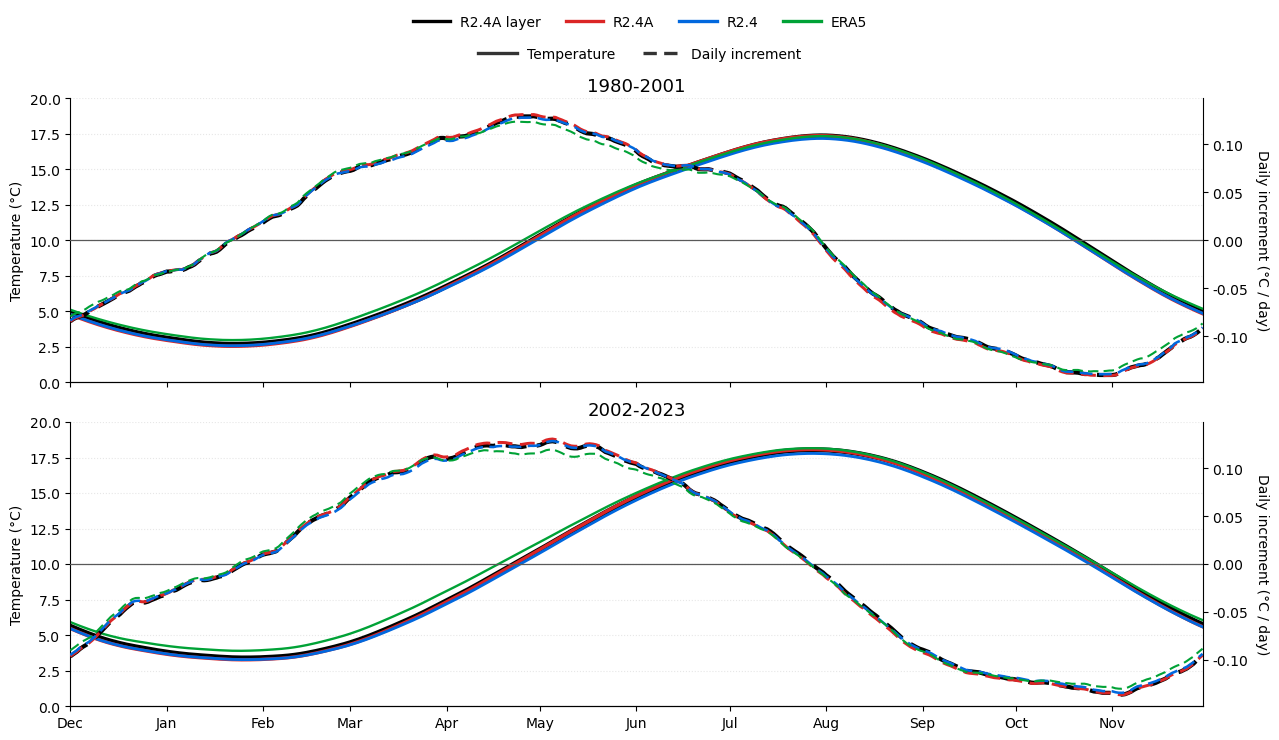

/tmp/ipykernel_1255768/512453903.py:384: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.90])


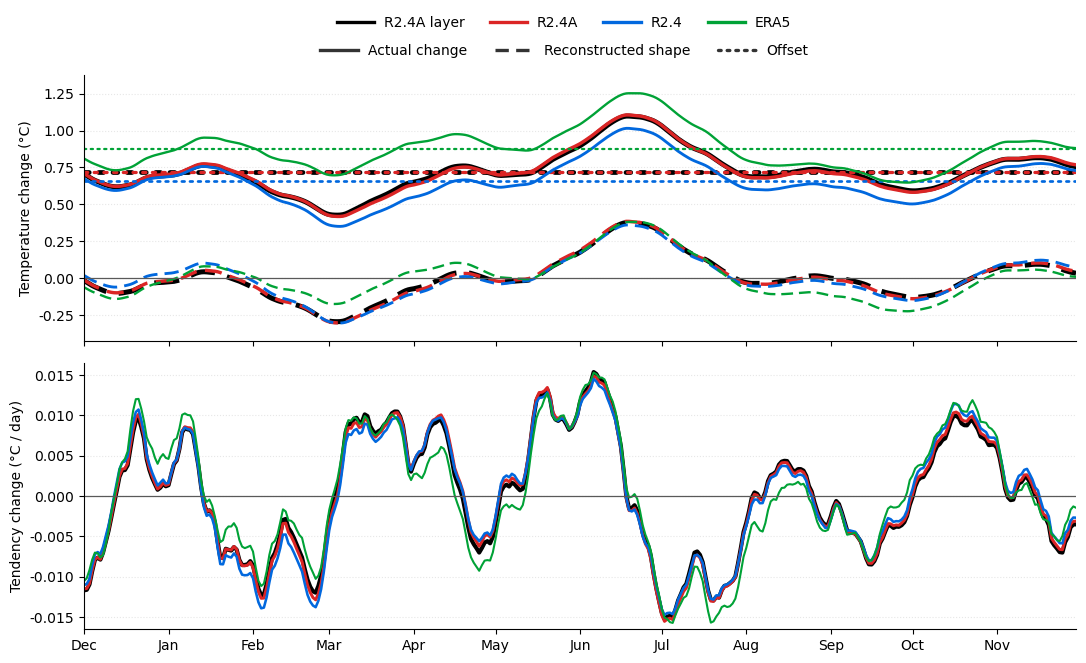

In [ ]:
from matplotlib.ticker import MaxNLocator, MultipleLocator, FormatStrFormatter, ScalarFormatter

selected_series = [
    ('RACMO2.4A', 'templ1', 'R2.4A layer'),
    ('RACMO2.4A', 'Tg',     'R2.4A'),
    ('RACMO2.4R', 'Tg',     'R2.4'),
    ('ERA5',      'Tg',     'ERA5'),
]

series = []
for i, (ds, var, label) in enumerate(selected_series):
    if ds not in clim_temp or var not in clim_temp[ds]:
        print(f'Skipping {ds} {var}, not found in clim_temp')
        continue
    if ds not in clim_tendtot or var not in clim_tendtot[ds]:
        print(f'Skipping {ds} {var}, not found in clim_tendtot')
        continue

    series.append({
        'dataset': ds,
        'var': var,
        'label': label,
        'color': COLORS[i % len(COLORS)],
        'lw_temp': [3.6, 2.45, 2.05, 1.70][i] if i < 4 else max(1.4, 1.70 - 0.10 * (i - 3)),
        'lw_tend': [3.0, 2.15, 1.85, 1.50][i] if i < 4 else max(1.2, 1.50 - 0.08 * (i - 3)),
    })

if not series:
    raise ValueError('No valid series found in selected_series')

# ------------------------------------------------------------------
# Shared x axis
# ------------------------------------------------------------------
ref = clim_temp[series[0]['dataset']][series[0]['var']]['PtrendL']
x = month_day_axis(ref['month_day'].values)
month_ticks = month_tick_positions()

# ------------------------------------------------------------------
# Line styles
# ------------------------------------------------------------------
legend_lw = 2.4

dash_daily_plot = (5.0, 2.5)
dash_shape_plot = (5.0, 2.5)
dot_offset_plot = (1.0, 2.0)

dash_daily_leg = (4.0, 2.2)
dash_shape_leg = (4.0, 2.2)
dot_offset_leg = (0.8, 1.8)

dataset_handles = [
    Line2D([0], [0], color=s['color'], lw=legend_lw, label=s['label'])
    for s in series
]

# ------------------------------------------------------------------
# Collect plot data and limits
# ------------------------------------------------------------------
temp_all = []
tend_all = []
dtemp_all = []
recon_shape_all = []
offset_all = []
dtend_all = []

plot_data = {}

for s in series:
    ds, var, label = s['dataset'], s['var'], s['label']

    temp_L = clim_temp[ds][var]['PtrendL']
    temp_R = clim_temp[ds][var]['PtrendR']
    tend_L = clim_tendtot[ds][var]['PtrendL']
    tend_R = clim_tendtot[ds][var]['PtrendR']

    dtemp = (temp_R - temp_L).astype('float32')
    dtend = (tend_R - tend_L).astype('float32')

    recon_shape = shape_tendtot[ds]['day']['Ptrend'][var]['Theta'].astype('float32')
    recon_shape = recon_shape.sel(month_day=dtemp['month_day'])

    offset_value = float(
        annual_offset_tendtot[ds]['day']['Ptrend'][var]['offset']['total'].item()
    )
    offset_line = xr.full_like(dtemp, offset_value).astype('float32')

    plot_data[label] = {
        'temp_L': temp_L,
        'temp_R': temp_R,
        'tend_L': tend_L,
        'tend_R': tend_R,
        'dtemp': dtemp,
        'dtend': dtend,
        'recon_shape': recon_shape,
        'offset_line': offset_line,
    }

    temp_all.extend([temp_L.values, temp_R.values])
    tend_all.extend([tend_L.values, tend_R.values])
    dtemp_all.append(dtemp.values)
    recon_shape_all.append(recon_shape.values)
    offset_all.append(offset_line.values)
    dtend_all.append(dtend.values)

temp_all = np.concatenate(temp_all)
tend_all = np.concatenate(tend_all)
dtemp_all = np.concatenate(dtemp_all)
recon_shape_all = np.concatenate(recon_shape_all)
offset_all = np.concatenate(offset_all)
dtend_all = np.concatenate(dtend_all)
trend_scale = 10.0 / float(offset_L['Ptrend'].item())

def padded_ylim(values, pad_frac=0.08, include_zero=False):
    ymin = float(np.nanmin(values))
    ymax = float(np.nanmax(values))

    if include_zero:
        ymin = min(ymin, 0.0)
        ymax = max(ymax, 0.0)

    pad = pad_frac * max(ymax - ymin, 1e-6)
    return ymin - pad, ymax + pad

temp_ylim = (0, 20)

tend_lim = 1.05 * np.nanmax(np.abs(tend_all))
tend_ylim = (-tend_lim, tend_lim)

change_ylim = padded_ylim(
    np.concatenate([dtemp_all, recon_shape_all, offset_all]),
    pad_frac=0.08,
    include_zero=True,
)

dtend_lim = 1.05 * np.nanmax(np.abs(dtend_all))
dtend_ylim = (-dtend_lim, dtend_lim)

# ------------------------------------------------------------------
# Figure 1, climatologies by period with twin axes
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(13.4, 8.0),
    sharex=True,
    gridspec_kw={'hspace': 0.14},
)

period_info = [
    ('PtrendL', period_label('PtrendL')),
    ('PtrendR', period_label('PtrendR')),
]

twin_axes = []

for ax, (period_key, title) in zip(axes, period_info):
    ax2 = ax.twinx()
    twin_axes.append(ax2)

    for s in series:
        label = s['label']
        d = plot_data[label]

        temp = d['temp_L'] if period_key == 'PtrendL' else d['temp_R']
        tend = d['tend_L'] if period_key == 'PtrendL' else d['tend_R']

        ax.plot(
            x,
            temp,
            color=s['color'],
            lw=s['lw_temp'],
            ls='-',
        )

        ax2.plot(
            x,
            tend,
            color=s['color'],
            lw=s['lw_tend'],
            ls='--',
            dashes=dash_daily_plot,
        )

    ax.set_title(title, fontsize=13, pad=5)
    ax.set_ylim(temp_ylim)
    ax2.set_ylim(tend_ylim)

    ax.yaxis.set_major_locator(MultipleLocator(2.5))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    ax2.yaxis.set_major_locator(MultipleLocator(0.05))
    ax2.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    ax.grid(axis='y', linestyle=':', alpha=0.30)
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax2.spines['left'].set_visible(False)

    ax2.axhline(0, color='0.35', lw=0.9, zorder=0)

    ax.set_xlim(x[0], x[-1])
    ax2.set_xlim(x[0], x[-1])
    ax.margins(x=0)
    ax2.margins(x=0)

axes[-1].set_xticks(month_ticks)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[-1].tick_params(axis='x', labelsize=10)

axes[0].set_ylabel('Temperature (°C)')
axes[1].set_ylabel('Temperature (°C)')

twin_axes[0].set_ylabel(
    'Daily increment (°C / day)',
    rotation=270,
    labelpad=10,
    va='center',
)

twin_axes[1].set_ylabel(
    'Daily increment (°C / day)',
    rotation=270,
    labelpad=10,
    va='center',
)

style_handles_fig1 = [
    Line2D([0], [0], color='0.2', lw=legend_lw, ls='-', label='Temperature'),
    Line2D(
        [0], [0],
        color='0.2',
        lw=legend_lw,
        ls='--',
        dashes=dash_daily_leg,
        label='Daily increment',
    ),
]

fig.legend(
    handles=dataset_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.96),
    ncol=len(dataset_handles),
    frameon=False,
    handlelength=2.7,
    handletextpad=0.7,
    columnspacing=1.8,
)

fig.legend(
    handles=style_handles_fig1,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.92),
    ncol=2,
    frameon=False,
    handlelength=2.8,
    handletextpad=0.7,
    columnspacing=2.0,
)

fig.subplots_adjust(
    left=0.075,
    right=0.92,
    bottom=0.08,
    top=0.84,
    hspace=0.14,
)

plt.show()

# ------------------------------------------------------------------
# Figure 2, true temperature change, reconstructed shape, and offset
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(13.4, 7.2),
    sharex=True,
    gridspec_kw={'hspace': 0.08},
)

ax_top, ax_bot = axes

for s in series:
    label = s['label']
    d = plot_data[label]

    ax_top.plot(
        x,
        d['dtemp'],
        color=s['color'],
        lw=s['lw_temp'],
        ls='-',
    )

    ax_top.plot(
        x,
        d['recon_shape'],
        color=s['color'],
        lw=s['lw_temp'],
        ls='--',
        dashes=dash_shape_plot,
    )

    ax_top.plot(
        x,
        d['offset_line'],
        color=s['color'],
        lw=s['lw_temp'] * 0.95,
        ls=':',
        dashes=dot_offset_plot,
        dash_capstyle='round',
    )

    ax_bot.plot(
        x,
        d['dtend'],
        color=s['color'],
        lw=s['lw_tend'],
        ls='-',
    )

for ax in axes:
    ax.grid(axis='y', linestyle=':', alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.axhline(0, color='0.35', lw=0.9)

    ax.set_xlim(x[0], x[-1])
    ax.margins(x=0)

ax_top.set_ylim(change_ylim)
ax_bot.set_ylim(dtend_ylim)

ax_top_trend = ax_top.secondary_yaxis(
    'right',
    functions=(lambda y: y * trend_scale, lambda y: y / trend_scale),
)
ax_bot_trend = ax_bot.secondary_yaxis(
    'right',
    functions=(lambda y: y * trend_scale, lambda y: y / trend_scale),
)
ax_top_trend.set_ylabel('Temperature-change trend (°C / decade)', rotation=270, labelpad=13, va='center')
ax_bot_trend.set_ylabel('Tendency-change trend (°C / day / decade)', rotation=270, labelpad=13, va='center')

ax_top_trend.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax_top_trend.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

tend_trend_formatter = ScalarFormatter(useMathText=True)
tend_trend_formatter.set_powerlimits((-2, -2))
ax_bot_trend.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax_bot_trend.yaxis.set_major_formatter(tend_trend_formatter)

for ax_trend in [ax_top_trend, ax_bot_trend]:
    ax_trend.spines['top'].set_visible(False)

ax_top.set_ylabel('Temperature change (°C)')
ax_bot.set_ylabel('Tendency change (°C / day)')

ax_bot.set_xticks(month_ticks)
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax_bot.tick_params(axis='x', labelsize=10)

style_handles_fig2 = [
    Line2D([0], [0], color='0.2', lw=legend_lw, ls='-', label='Actual change'),
    Line2D(
        [0], [0],
        color='0.2',
        lw=legend_lw,
        ls='--',
        dashes=dash_shape_leg,
        label='Reconstructed shape',
    ),
    Line2D(
        [0], [0],
        color='0.2',
        lw=legend_lw,
        ls=':',
        dashes=dot_offset_leg,
        dash_capstyle='round',
        label='Offset',
    ),
]

fig.legend(
    handles=dataset_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=len(dataset_handles),
    frameon=False,
    handlelength=2.7,
    handletextpad=0.7,
    columnspacing=1.8,
)

fig.legend(
    handles=style_handles_fig2,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.94),
    ncol=3,
    frameon=False,
    handlelength=2.8,
    handletextpad=0.7,
    columnspacing=2.0,
)

fig.subplots_adjust(
    left=0.075,
    right=0.92,
    bottom=0.08,
    top=0.88,
    hspace=0.08,
)
plt.show()


# Change here

In [ ]:
# Figure 2
from matplotlib.ticker import MaxNLocator, MultipleLocator

datasets = [ds for ds in clim_temp if 'Tg' in clim_temp[ds]]

series = []

if 'RACMO2.4A' in clim_temp and 'templ1' in clim_temp['RACMO2.4A']:
    series.append({
        'dataset': 'RACMO2.4A',
        'var': 'templ1',
        'label': 'R2.4A layer',
    })

for ds in datasets:
    series.append({
        'dataset': ds,
        'var': 'Tg',
        'label': name_map.get(ds, ds),
    })

for i, s in enumerate(series):
    s['color'] = COLORS[i % len(COLORS)]
    s['edgecolor'] = 'black'
    s['linewidth'] = 0.8

handles = [
    Patch(
        facecolor=s['color'],
        edgecolor=s['edgecolor'],
        linewidth=s['linewidth'],
        label=s['label'],
    )
    for s in series
]

pair_to_period = {
    ('PrefL', 'PrefR'): 'Pref',
    ('PtrendL', 'PtrendR'): 'Ptrend',
}

season_order_main = ['DJF', 'MAM', 'JJA', 'SON', 'ALL']
season_order_rel = ['DJF', 'MAM', 'JJA', 'SON']
y_main = np.array([0.0, 1.0, 2.0, 3.0, 4.35])
y_rel = np.arange(len(season_order_rel), dtype=float)
bar_height = min(0.12, 0.74 / max(len(series), 1))


def smart_xlim(values, pad_frac=0.10, include_zero=True):
    xmin = float(np.nanmin(values))
    xmax = float(np.nanmax(values))

    if include_zero and xmin >= 0.0:
        pad = pad_frac * max(xmax, 1e-6)
        return 0.0, xmax + pad

    if include_zero and xmax <= 0.0:
        pad = pad_frac * max(abs(xmin), 1e-6)
        return xmin - pad, 0.0

    if include_zero:
        xmin = min(xmin, 0.0)
        xmax = max(xmax, 0.0)

    pad = pad_frac * max(xmax - xmin, 1e-6)
    return xmin - pad, xmax + pad


def draw_grouped_hbars(ax, values, seasons, y):
    for i, s in enumerate(series):
        offset = (i - (len(series) - 1) / 2) * bar_height
        vals = values[s['label']].sel(season=seasons).values

        ax.barh(
            y + offset,
            vals,
            height=bar_height,
            color=s['color'],
            edgecolor=s['edgecolor'],
            linewidth=s['linewidth'],
            zorder=3,
        )

    ax.set_yticks(y)
    ax.set_yticklabels(seasons)
    ax.set_ylim(y[-1] + 0.55, y[0] - 0.55)

    if 'ALL' in seasons:
        ax.axhline(3.68, color='0.62', lw=0.8, ls=':', zorder=1)


def style_hbar_axis(ax, title, xlabel, zero=False, xfmt='%.2f'):
    if zero:
        ax.axvline(0, color='0.20', lw=0.9, zorder=1)

    ax.grid(axis='x', linestyle=':', alpha=0.30)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.xaxis.set_major_formatter(FormatStrFormatter(xfmt))
    ax.set_xlabel(xlabel, labelpad=7)
    ax.set_title(title, fontsize=12, fontweight='normal', pad=7)


def _ticks_for_step(xlim, step):
    start = np.ceil(xlim[0] / step) * step
    stop = np.floor(xlim[1] / step) * step
    return np.round(np.arange(start, stop + 0.5 * step, step), 10)


def _change_tick_step(xlim):
    if (xlim[1] - xlim[0]) <= 0.35:
        return 0.05
    if len(_ticks_for_step(xlim, 0.1)) <= 11:
        return 0.1
    return 0.2


def _change_tick_formatter(step):
    return FormatStrFormatter('%.2f' if step < 0.1 else '%.1f')


def set_change_ticks(ax, xlim):
    step = _change_tick_step(xlim)
    ax.set_xticks(_ticks_for_step(xlim, step))
    ax.xaxis.set_major_formatter(_change_tick_formatter(step))


def add_trend_axis(ax, L, label, steps=(0.05, 0.1, 0.2)):
    factor = 10.0 / L
    top_xlim = tuple(value * factor for value in ax.get_xlim())
    step = next(
        (candidate for candidate in steps if len(_ticks_for_step(top_xlim, candidate)) <= 9),
        steps[-1],
    )

    secax = ax.secondary_xaxis(
        'top',
        functions=(
            lambda x: x * factor,
            lambda x: x / factor,
        ),
    )
    secax.set_xlabel(label, labelpad=6)
    secax.set_xticks(_ticks_for_step(top_xlim, step))
    secax.xaxis.set_major_formatter(_change_tick_formatter(step))
    secax.tick_params(axis='x', labelrotation=0, pad=2)
    return secax


for left_key, right_key in [('PrefL', 'PrefR'), ('PtrendL', 'PtrendR')]:
    period_key = pair_to_period[(left_key, right_key)]

    seasonal = {}
    relative = {}

    for s in series:
        ds, var, label = s['dataset'], s['var'], s['label']

        left_season = aggregate_calendar(
            clim_temp[ds][var][left_key],
            split='season',
            how='mean',
        )

        right_season = aggregate_calendar(
            clim_temp[ds][var][right_key],
            split='season',
            how='mean',
        )

        left_all = xr.DataArray(
            [clim_temp[ds][var][left_key].mean('month_day').astype('float32').item()],
            dims='season',
            coords={'season': ['ALL']},
        )

        right_all = xr.DataArray(
            [clim_temp[ds][var][right_key].mean('month_day').astype('float32').item()],
            dims='season',
            coords={'season': ['ALL']},
        )

        left = xr.concat([left_season, left_all], dim='season').sel(season=season_order_main)
        right = xr.concat([right_season, right_all], dim='season').sel(season=season_order_main)

        seasonal[label] = {
            left_key: left,
            right_key: right,
            'Diff': (right - left).astype('float32'),
        }

        relative[label] = (
            shape_tendtot[ds]['season'][period_key][var]['Theta']
            .sel(season=season_order_rel)
            .astype('float32')
        )

    temp_vals = np.concatenate([
        seasonal[s['label']][period_key_plot].values
        for s in series
        for period_key_plot in [left_key, right_key]
    ])
    diff_vals = np.concatenate([
        seasonal[s['label']]['Diff'].values for s in series
    ])
    rel_vals = np.concatenate([
        relative[s['label']].values for s in series
    ])

    temp_xlim = smart_xlim(temp_vals, pad_frac=0.04, include_zero=True)
    diff_xlim = smart_xlim(diff_vals, pad_frac=0.10, include_zero=True)
    rel_xlim = smart_xlim(rel_vals, pad_frac=0.12, include_zero=True)

    fig, axes = plt.subplots(
        1, 4,
        figsize=(18.8, 6.4),
        gridspec_kw={
            'width_ratios': [1.08, 1.08, 1.25, 1.05],
            'wspace': 0.24,
        },
    )
    fig.subplots_adjust(left=0.055, right=0.985, bottom=0.13, top=0.84)

    ax0, ax1, ax2, ax3 = axes

    draw_grouped_hbars(
        ax0,
        {s['label']: seasonal[s['label']][left_key] for s in series},
        season_order_main,
        y_main,
    )
    draw_grouped_hbars(
        ax1,
        {s['label']: seasonal[s['label']][right_key] for s in series},
        season_order_main,
        y_main,
    )
    draw_grouped_hbars(
        ax2,
        {s['label']: seasonal[s['label']]['Diff'] for s in series},
        season_order_main,
        y_main,
    )
    draw_grouped_hbars(ax3, relative, season_order_rel, y_rel)

    style_hbar_axis(ax0, period_label(left_key), 'Temperature (°C)', xfmt='%.1f')
    style_hbar_axis(ax1, period_label(right_key), 'Temperature (°C)', xfmt='%.1f')
    style_hbar_axis(ax2, 'Period change', 'Temperature change (°C)', zero=True, xfmt='%.2f')
    style_hbar_axis(ax3, 'Relative change', 'Relative change (°C)', zero=True, xfmt='%.2f')

    ax0.set_xlim(*temp_xlim)
    ax1.set_xlim(*temp_xlim)
    ax2.set_xlim(*diff_xlim)
    ax3.set_xlim(*rel_xlim)
    set_change_ticks(ax2, diff_xlim)
    set_change_ticks(ax3, rel_xlim)

    L = float(weights_kappa(periods[left_key], periods[right_key]).sum('year').item())
    add_trend_axis(ax2, L, 'Trend (°C / decade)')
    add_trend_axis(ax3, L, 'Relative trend (°C / decade)', steps=(0.02, 0.05, 0.1, 0.2))

    fig.legend(
        handles=handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.975),
        ncol=len(handles),
        frameon=False,
        columnspacing=1.6,
        handletextpad=0.6,
    )

    plt.show()


In [ ]:
# Cleanup here

from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

selected_series = [
    ('RACMO2.4A', 'templ1', 'R2.4A layer'),
    ('RACMO2.4A', 'Tg',     'R2.4A'),
    ('RACMO2.4R', 'Tg',     'R2.4'),
    ('ERA5',      'Tg',     'ERA5'),
]

period_keys = ['Pref', 'Ptrend']
dash_increment = (4.0, 2.2)


def _to_float(value):
    value = value.squeeze(drop=True)
    if hasattr(value.data, 'compute'):
        value = value.compute()
    return float(value.item())


def _daily_split(ds, var, period_key):
    da = annual_offset_tendtot[ds]['day'][period_key][var]['trend']['split']
    da = da.squeeze(drop=True).astype('float32')

    if 'month_day' not in da.dims:
        raise ValueError(f'{ds} {var} {period_key} has no month_day dimension')

    other_dims = [dim for dim in da.dims if dim != 'month_day']
    if other_dims:
        raise ValueError(f'{ds} {var} {period_key} still has unexpected dimensions: {other_dims}')

    return da.transpose('month_day')


def _symmetric_ylim(values, pad_frac=0.08):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return -1.0, 1.0

    lim = (1.0 + pad_frac) * max(float(np.nanmax(np.abs(values))), 1e-9)
    return -lim, lim


def _stack(values):
    return np.concatenate([np.asarray(value, dtype=float).ravel() for value in values])


def _style_axis(ax, bottom=False):
    ax.axhline(0, color='0.25', lw=0.85, zorder=1)
    ax.grid(axis='y', linestyle=':', alpha=0.30)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    ax.set_xlim(x[0], x[-1])
    ax.margins(x=0)

    if bottom:
        ax.set_xticks(month_ticks)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        ax.set_xlabel('Calendar day')
    else:
        ax.tick_params(axis='x', labelbottom=False)


series = []
plot_data = {}

for i, (ds, var, label) in enumerate(selected_series):
    try:
        pref = _daily_split(ds, var, 'Pref')
        ptrend = _daily_split(ds, var, 'Ptrend')
    except KeyError:
        print(f'Skipping {ds} {var}, not found in annual_offset_tendtot')
        continue

    for period_key, daily in [('Pref', pref), ('Ptrend', ptrend)]:
        split_total = _to_float(daily.sum('month_day'))
        stored_total = _to_float(annual_offset_tendtot[ds]['day'][period_key][var]['trend']['total'])
        if not np.isclose(split_total, stored_total, rtol=1e-4, atol=1e-7):
            print(
                f'Check {ds} {var} {period_key}: '
                f'daily split sums to {split_total:.4g}, stored total is {stored_total:.4g}'
            )

    change = (ptrend - pref).astype('float32')

    series.append({
        'dataset': ds,
        'var': var,
        'label': label,
        'color': COLORS[i % len(COLORS)],
        'lw_cumulative': [3.4, 2.45, 2.10, 1.75][i] if i < 4 else 1.55,
        'lw_increment': [2.25, 1.85, 1.60, 1.35][i] if i < 4 else 1.20,
    })

    plot_data[label] = {
        'Pref': pref,
        'Ptrend': ptrend,
        'Change': change,
    }

if not series:
    raise ValueError('No valid series found in selected_series')

ref = plot_data[series[0]['label']]['Ptrend']
x = month_day_axis(ref['month_day'].values)
month_ticks = month_tick_positions()

period_titles = {
    'Pref': f'Reference ({period_label("Pref")})',
    'Ptrend': f'Trend ({period_label("Ptrend")})',
    'Change': 'Trend minus reference',
}

cumulative_period_values = []
increment_period_values = []
cumulative_change_values = []
increment_change_values = []

for s in series:
    label = s['label']

    for key in ['Pref', 'Ptrend']:
        daily = plot_data[label][key]
        cumulative_period_values.append(daily.cumsum('month_day').values)
        increment_period_values.append(daily.values)

    daily_change = plot_data[label]['Change']
    cumulative_change_values.append(daily_change.cumsum('month_day').values)
    increment_change_values.append(daily_change.values)

cumulative_period_ylim = _symmetric_ylim(_stack(cumulative_period_values), pad_frac=0.10)
increment_period_ylim = _symmetric_ylim(_stack(increment_period_values), pad_frac=0.16)
cumulative_change_ylim = _symmetric_ylim(_stack(cumulative_change_values), pad_frac=0.12)
increment_change_ylim = _symmetric_ylim(_stack(increment_change_values), pad_frac=0.18)

fig, axes = plt.subplots(
    3, 1,
    figsize=(13.4, 8.4),
    sharex=True,
    gridspec_kw={'hspace': 0.14},
)
fig.subplots_adjust(top=0.84, left=0.075, right=0.92, bottom=0.09)

increment_axes = []

for row, key in enumerate(['Pref', 'Ptrend', 'Change']):
    ax = axes[row]
    ax_inc = ax.twinx()
    increment_axes.append(ax_inc)

    for s in series:
        label = s['label']
        daily = plot_data[label][key]
        cumulative = daily.cumsum('month_day').astype('float32')

        ax.plot(
            x,
            cumulative.values,
            color=s['color'],
            lw=s['lw_cumulative'],
            solid_capstyle='round',
            zorder=4,
        )
        ax.scatter(
            x[-1],
            cumulative.isel(month_day=-1).values,
            s=25,
            color=s['color'],
            edgecolor='white',
            linewidth=0.7,
            zorder=5,
        )
        ax_inc.plot(
            x,
            daily.values,
            color=s['color'],
            lw=s['lw_increment'],
            ls='--',
            dashes=dash_increment,
            alpha=0.72,
            solid_capstyle='round',
            zorder=3,
        )

    ax.text(
        0.012, 0.91, period_titles[key],
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=11.5,
        fontweight='semibold',
        bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.86, 'pad': 2.2},
    )

    _style_axis(ax, bottom=row == 2)

    ax_inc.spines['top'].set_visible(False)
    ax_inc.spines['left'].set_visible(False)
    ax_inc.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax_inc.yaxis.set_major_formatter(FormatStrFormatter('%.5f'))
    ax_inc.tick_params(axis='y', colors='0.35')
    ax_inc.spines['right'].set_color('0.55')
    ax_inc.set_xlim(x[0], x[-1])
    ax_inc.margins(x=0)

    if key == 'Change':
        ax.set_ylim(cumulative_change_ylim)
        ax_inc.set_ylim(increment_change_ylim)
    else:
        ax.set_ylim(cumulative_period_ylim)
        ax_inc.set_ylim(increment_period_ylim)

axes[1].set_ylabel('Cumulative annual offset (°C / year)')
increment_axes[1].set_ylabel('Daily contribution (°C / year)', rotation=270, labelpad=16, color='0.30')

handles = [
    Line2D([0], [0], color=s['color'], lw=2.6, label=s['label'])
    for s in series
]
style_handles = [
    Line2D([0], [0], color='0.20', lw=2.4, label='Cumulative'),
    Line2D([0], [0], color='0.20', lw=1.8, ls='--', dashes=dash_increment, label='Daily contribution'),
    Line2D([0], [0], color='0.20', marker='o', lw=0, markersize=5.5, markerfacecolor='0.20', markeredgecolor='white', label='Annual offset'),
]

fig.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.985),
    ncol=len(handles),
    frameon=False,
    handlelength=2.7,
    columnspacing=1.55,
)
fig.legend(
    handles=style_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.925),
    ncol=len(style_handles),
    frameon=False,
    handlelength=2.7,
    columnspacing=1.70,
)

plt.show()


In [ ]:
# Cleanup here

from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

datasets = [ds for ds in clim_temp if 'Tg' in clim_temp[ds]]
season_names = ['DJF', 'MAM', 'JJA', 'SON']
annual_scale = 10.0


def _to_float(value):
    value = value.squeeze(drop=True)
    if hasattr(value.data, 'compute'):
        value = value.compute()
    return float(value.item())


def _seasonal_split(ds, var, period_key):
    da = annual_offset_tendtot[ds]['season'][period_key][var]['trend']['split']
    da = da.squeeze(drop=True).astype('float32')

    if 'season' not in da.dims:
        raise ValueError(f'{ds} {var} {period_key} has no season dimension')

    other_dims = [dim for dim in da.dims if dim != 'season']
    if other_dims:
        raise ValueError(f'{ds} {var} {period_key} still has unexpected dimensions: {other_dims}')

    return da.transpose('season').sel(season=season_names)


def _as_all(value):
    return xr.DataArray([value], dims='season', coords={'season': ['ALL']})


def _smart_xlim(values, pad_frac=0.08, include_zero=True):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return -1.0, 1.0

    xmin = float(np.nanmin(values))
    xmax = float(np.nanmax(values))

    if include_zero and xmin >= 0.0:
        pad = pad_frac * max(xmax, 1e-9)
        return 0.0, xmax + pad

    if include_zero and xmax <= 0.0:
        pad = pad_frac * max(abs(xmin), 1e-9)
        return xmin - pad, 0.0

    if include_zero:
        xmin = min(xmin, 0.0)
        xmax = max(xmax, 0.0)

    pad = pad_frac * max(xmax - xmin, 1e-9)
    return xmin - pad, xmax + pad


def _draw_grouped_hbars(ax, values, seasons, y, height):
    for i, s in enumerate(series):
        offset = (i - (len(series) - 1) / 2) * height
        vals = values[s['label']].sel(season=seasons).values

        ax.barh(
            y + offset,
            vals,
            height=height,
            color=s['color'],
            edgecolor=s['edgecolor'],
            linewidth=s['linewidth'],
            zorder=3,
        )

    ax.set_yticks(y)
    ax.set_yticklabels(seasons)
    ax.set_ylim(y[-1] + 0.52, y[0] - 0.52)


def _style_hbar_axis(ax, title=None, xlabel=None, zero=True, formatter='%.1f'):
    if zero:
        ax.axvline(0, color='0.25', lw=0.85, zorder=1)

    ax.grid(axis='x', linestyle=':', alpha=0.30)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.xaxis.set_major_formatter(FormatStrFormatter(formatter))

    if title is not None:
        ax.set_title(title, fontsize=12.5, fontweight='bold', pad=7)
    if xlabel is not None:
        ax.set_xlabel(xlabel, labelpad=7)


def _formatter_for_xlim(xlim):
    span = abs(xlim[1] - xlim[0])
    if span >= 5.0:
        return FormatStrFormatter('%.0f')
    if span >= 0.5:
        return FormatStrFormatter('%.1f')
    return FormatStrFormatter('%.2f')


def _ticks_for_step(xlim, step):
    start = np.ceil(xlim[0] / step) * step
    stop = np.floor(xlim[1] / step) * step
    return np.round(np.arange(start, stop + 0.5 * step, step), 10)


def _formatter_for_step(step):
    if step >= 1.0:
        return FormatStrFormatter('%.0f')
    if step < 0.1:
        return FormatStrFormatter('%.2f')
    return FormatStrFormatter('%.1f')


def _set_annual_ticks(ax):
    xlim = ax.get_xlim()
    span = abs(xlim[1] - xlim[0])
    step = 0.05 if span <= 0.35 else 0.1 if span <= 1.0 else 0.2
    ax.set_xticks(_ticks_for_step(xlim, step))
    ax.set_xlim(*xlim)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f' if step == 0.05 else '%.1f'))


def _format_season_ticks(ax):
    xlim = ax.get_xlim()
    span = abs(xlim[1] - xlim[0])
    if span >= 8.0:
        step = 4.0
    elif span >= 1.0:
        step = 0.2
    elif span >= 0.35:
        step = 0.1
    else:
        step = 0.05

    ax.set_xticks(_ticks_for_step(xlim, step))
    ax.set_xlim(*xlim)
    ax.xaxis.set_major_formatter(_formatter_for_step(step))


series = []

if 'RACMO2.4A' in clim_temp and 'templ1' in clim_temp['RACMO2.4A']:
    series.append({
        'dataset': 'RACMO2.4A',
        'var': 'templ1',
        'label': 'R2.4A layer',
    })

for ds in datasets:
    series.append({
        'dataset': ds,
        'var': 'Tg',
        'label': name_map.get(ds, ds),
    })

valid_series = []
for i, s in enumerate(series):
    ds, var = s['dataset'], s['var']

    try:
        pref = _seasonal_split(ds, var, 'Pref')
        ptrend = _seasonal_split(ds, var, 'Ptrend')
    except KeyError:
        print(f'Skipping {ds} {var}, not found in annual_offset_tendtot')
        continue

    for period_key, split in [('Pref', pref), ('Ptrend', ptrend)]:
        split_total = _to_float(split.sum('season'))
        stored_total = _to_float(annual_offset_tendtot[ds]['season'][period_key][var]['trend']['total'])
        if not np.isclose(split_total, stored_total, rtol=1e-4, atol=1e-7):
            print(
                f'Check {ds} {var} {period_key}: '
                f'seasonal split sums to {split_total:.4g}, stored total is {stored_total:.4g}'
            )

    annual_pref = annual_scale * _to_float(pref.sum('season'))
    annual_ptrend = annual_scale * _to_float(ptrend.sum('season'))

    s['color'] = COLORS[i % len(COLORS)]
    s['edgecolor'] = 'black'
    s['linewidth'] = 0.75
    s['Pref'] = pref
    s['Ptrend'] = ptrend
    s['Change'] = (ptrend - pref).astype('float32')
    s['AnnualPref'] = _as_all(annual_pref)
    s['AnnualPtrend'] = _as_all(annual_ptrend)
    s['AnnualChange'] = _as_all(annual_ptrend - annual_pref)
    valid_series.append(s)

series = valid_series
if not series:
    raise ValueError('No valid seasonal tendency series found')

season_values = np.concatenate([
    np.asarray(s[key].values, dtype=float).ravel()
    for s in series
    for key in ['Pref', 'Ptrend']
])
season_change_values = np.concatenate([
    np.asarray(s['Change'].values, dtype=float).ravel()
    for s in series
])
annual_values = np.concatenate([
    np.asarray(s[key].values, dtype=float).ravel()
    for s in series
    for key in ['AnnualPref', 'AnnualPtrend']
])
annual_change_values = np.concatenate([
    np.asarray(s['AnnualChange'].values, dtype=float).ravel()
    for s in series
])

season_xlim = _smart_xlim(season_values, pad_frac=0.10)
season_change_xlim = _smart_xlim(season_change_values, pad_frac=0.14)
annual_xlim = _smart_xlim(annual_values, pad_frac=0.10)
annual_change_xlim = _smart_xlim(annual_change_values, pad_frac=0.14)

y_season = np.arange(len(season_names), dtype=float)
y_annual = np.array([0.0])
height = min(0.12, 0.74 / len(series))
panel_info = [
    ('Pref', 'AnnualPref', f'Reference ({period_label("Pref")})'),
    ('Ptrend', 'AnnualPtrend', f'Trend ({period_label("Ptrend")})'),
    ('Change', 'AnnualChange', 'Trend minus reference'),
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(15.8, 7.0),
    gridspec_kw={
        'height_ratios': [2.75, 1.0],
        'hspace': 0.34,
        'wspace': 0.26,
    },
)
fig.subplots_adjust(top=0.86, left=0.075, right=0.99, bottom=0.105)

for col, (season_key, annual_key, title) in enumerate(panel_info):
    ax_season = axes[0, col]
    ax_annual = axes[1, col]

    seasonal_values = {s['label']: s[season_key] for s in series}
    annual_total_values = {s['label']: s[annual_key] for s in series}

    _draw_grouped_hbars(ax_season, seasonal_values, season_names, y_season, height)
    _draw_grouped_hbars(ax_annual, annual_total_values, ['ALL'], y_annual, height)

    _style_hbar_axis(
        ax_season,
        title=title,
        xlabel='Seasonal contribution (°C / year)' if season_key != 'Change' else 'Change in contribution (°C / year)',
        formatter='%.1f',
    )
    _style_hbar_axis(
        ax_annual,
        xlabel='Annual offset (°C / decade)' if annual_key != 'AnnualChange' else 'Change in annual offset (°C / decade)',
        formatter='%.1f',
    )

    if season_key == 'Change':
        ax_season.set_xlim(*season_change_xlim)
        ax_annual.set_xlim(*annual_change_xlim)
    else:
        ax_season.set_xlim(*season_xlim)
        ax_annual.set_xlim(*annual_xlim)

    _format_season_ticks(ax_season)
    _set_annual_ticks(ax_annual)

    if col != 0:
        ax_season.tick_params(axis='y', labelleft=False)
        ax_annual.tick_params(axis='y', labelleft=False)

handles = [
    Patch(
        facecolor=s['color'],
        edgecolor=s['edgecolor'],
        linewidth=s['linewidth'],
        label=s['label'],
    )
    for s in series
]

fig.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.96),
    ncol=len(handles),
    frameon=False,
    columnspacing=1.6,
    handletextpad=0.6,
    fontsize=12
)

plt.show()

In [ ]:
# Continue here

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator, FormatStrFormatter, ScalarFormatter, FuncFormatter

process_period = 'Ptrend'
reference_period = 'Pref'
process_left, process_right = offset_periods[process_period]
shape_seasons = ['DJF', 'MAM', 'JJA', 'SON']
offset_seasons = ['DJF', 'MAM', 'JJA', 'SON', 'ALL']
annual_scale = 10.0
process_L = float(offset_L[process_period].item())
shape_to_year = 1.0 / process_L
shape_to_decade = annual_scale / process_L

process_label = {
    'tendtot': 'Total',
    'dyntot': 'Dynamics',
    'phystot': 'Physics',
    'numtot': 'Numerics',
    'radtot': 'Radiation',
    'swnet': 'SW net',
    'lwnet': 'LW net',
}


def _clean_1d(da, dim):
    da = da.squeeze(drop=True).astype('float32')
    extra_dims = [d for d in da.dims if d != dim]
    if extra_dims:
        raise ValueError(f'Expected only {dim}, found {extra_dims}')
    return da.transpose(dim)


def _to_float(value):
    value = value.squeeze(drop=True)
    if hasattr(value.data, 'compute'):
        value = value.compute()
    return float(value.item())


def _season_plus_all(season_da, all_value):
    all_da = xr.DataArray(
        [all_value],
        dims='season',
        coords={'season': ['ALL']},
    )
    return xr.concat([season_da, all_da], dim='season').sel(season=offset_seasons).astype('float32')


def _finite(values):
    values = np.asarray(values, dtype=float)
    return values[np.isfinite(values)]


def _smart_xlim(values, pad_frac=0.08, include_zero=True):
    values = _finite(values)
    if values.size == 0:
        return -1.0, 1.0

    xmin = float(values.min())
    xmax = float(values.max())

    if include_zero:
        if xmin >= 0.0:
            return 0.0, xmax + pad_frac * max(xmax, 1e-9)
        if xmax <= 0.0:
            return xmin - pad_frac * max(abs(xmin), 1e-9), 0.0
        xmin = min(xmin, 0.0)
        xmax = max(xmax, 0.0)

    pad = pad_frac * max(xmax - xmin, 1e-9)
    return xmin - pad, xmax + pad


def _symmetric_ylim(values, pad_frac=0.08):
    values = _finite(values)
    if values.size == 0:
        return -1.0, 1.0
    lim = (1.0 + pad_frac) * max(float(np.nanmax(np.abs(values))), 1e-9)
    return -lim, lim


def _format_axis(axis, span):
    axis.set_major_locator(MaxNLocator(nbins=5))

    if span < 0.06:
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_powerlimits((-2, 2))
        axis.set_major_formatter(formatter)
    elif span < 0.8:
        axis.set_major_formatter(FormatStrFormatter('%.2f'))
    elif span < 8.0:
        axis.set_major_formatter(FormatStrFormatter('%.1f'))
    else:
        axis.set_major_formatter(FormatStrFormatter('%.0f'))


def _style_calendar_axis(ax, ylabel=None):
    ax.axhline(0, color='0.25', lw=0.85, zorder=1)
    ax.grid(axis='y', linestyle=':', alpha=0.30)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(x[0], x[-1])
    ax.set_xticks(month_ticks)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    if ylabel is not None:
        ax.set_ylabel(ylabel)


def _style_twin_axis(ax, ylabel=None):
    ax.axhline(0, color='0.20', lw=0.75, alpha=0.55, zorder=1)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.grid(False)
    if ylabel is not None:
        ax.set_ylabel(ylabel, rotation=270, labelpad=6, va='center')


def _finish_y_ticks(*axes):
    for ax in axes:
        ymin, ymax = ax.get_ylim()
        _format_axis(ax.yaxis, abs(ymax - ymin))


def _format_matrix_value(value):
    value = float(value)
    abs_value = abs(value)
    if abs_value >= 100.0:
        return f'{value:.0f}'
    if abs_value >= 10.0:
        return f'{value:.1f}'
    if abs_value >= 1.0:
        return f'{value:.2f}'
    if abs_value >= 0.1:
        return f'{value:.2f}'
    if abs_value >= 0.01:
        return f'{value:.3f}'
    if abs_value >= 0.001:
        return f'{value:.3f}'
    return f'{value:.1e}'


def _compact_tick(value, _pos=None):
    value = float(value)
    if np.isclose(value, 0.0, atol=1e-14):
        return '0'

    abs_value = abs(value)
    if abs_value >= 10.0:
        label = f'{value:.0f}' if np.isclose(value, round(value)) else f'{value:.1f}'
    elif abs_value >= 1.0:
        label = f'{value:.1f}'
    elif abs_value >= 0.1:
        label = f'{value:.2f}'
    else:
        label = f'{value:.2g}'

    return label.rstrip('0').rstrip('.') if '.' in label else label


def _set_budget_axis(ax, limit, nticks=5):
    ax.set_xlim(-limit, limit)
    ax.set_xticks(np.linspace(-limit, limit, nticks))
    ax.xaxis.set_major_formatter(FuncFormatter(_compact_tick))


def _nice_bar_limit(value):
    value = abs(float(value))
    if value == 0.0 or not np.isfinite(value):
        return 1.0
    power = 10.0 ** np.floor(np.log10(value))
    for multiplier in [1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0]:
        candidate = multiplier * power
        if candidate >= value:
            return candidate
    return 10.0 * power


def _season_stack_extent(component_values, season, scale=1.0):
    pos_sum = 0.0
    neg_sum = 0.0
    for values in component_values.values():
        value = scale * float(values.sel(season=season))
        if value >= 0.0:
            pos_sum += value
        else:
            neg_sum += value
    return neg_sum, pos_sum


def _draw_one_season_budget(
    ax,
    component_values,
    total,
    total_limit,
    season,
    component_order,
    colors,
    component_unit,
    total_unit,
    component_scale=1.0,
    total_nticks=5,
):
    neg_sum, pos_sum = _season_stack_extent(component_values, season, scale=component_scale)
    component_limit = _nice_bar_limit(1.10 * max(abs(neg_sum), abs(pos_sum), 1e-12))

    pos_left = 0.0
    neg_left = 0.0
    for var in component_order:
        value = component_scale * float(component_values[var].sel(season=season))
        start = pos_left if value >= 0.0 else neg_left
        end = start + value
        pos_left = end if value >= 0.0 else pos_left
        neg_left = end if value < 0.0 else neg_left
        if np.isclose(start, end):
            continue
        ax.barh(
            -0.11,
            abs(end - start),
            left=min(start, end),
            height=0.10,
            color=colors[var],
            edgecolor='black',
            linewidth=0.62,
            zorder=3,
        )

    ax.axvline(0, color='0.25', lw=0.85, zorder=2)
    ax.grid(axis='x', linestyle=':', alpha=0.28)
    ax.set_axisbelow(True)
    _set_budget_axis(ax, component_limit, nticks=5)
    ax.set_ylim(-0.23, 0.23)
    ax.text(
        0.5,
        0.94,
        season,
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=9.2,
        zorder=6,
    )
    ax.set_yticks([])
    ax.tick_params(axis='x', labelsize=7.6, pad=1.2)
    ax.tick_params(axis='y', length=0)
    for spine in ['right', 'left']:
        ax.spines[spine].set_visible(False)
    ax_total = ax.twiny()
    ax_total.patch.set_visible(False)
    _set_budget_axis(ax_total, total_limit, nticks=total_nticks)
    ax_total.set_ylim(ax.get_ylim())
    ax_total.axvline(0, color='black', lw=0.75, alpha=0.50, zorder=2)
    ax_total.barh(
        0.11,
        abs(total),
        left=min(0.0, total),
        height=0.065,
        color='black',
        edgecolor='black',
        linewidth=0.55,
        zorder=5,
    )
    top_labelsize = 6.6 if total_nticks >= 5 else 7.0
    ax_total.tick_params(axis='x', labelsize=top_labelsize, pad=0.8)
    ax_total.tick_params(axis='y', left=False, labelleft=False)
    for spine in ['right', 'left', 'bottom']:
        ax_total.spines[spine].set_visible(False)

def _draw_budget_panel(
    fig,
    parent_spec,
    title,
    component_values,
    total_values,
    seasons,
    component_order,
    colors,
    component_unit,
    total_unit,
    component_scale=1.0,
    total_scale=1.0,
):
    n_seasons = len(seasons)
    gs = parent_spec.subgridspec(
        2,
        n_seasons,
        height_ratios=[0.24, 1.00],
        hspace=0.26,
        wspace=0.20,
    )
    title_ax = fig.add_subplot(gs[0, :])
    title_ax.axis('off')
    title_ax.axis('off')

    totals = total_scale * np.asarray([float(total_values.sel(season=season)) for season in seasons], dtype=float)
    seasonal_totals = totals[[season != 'ALL' for season in seasons]]
    seasonal_total_limit = _nice_bar_limit(1.15 * max(np.nanmax(np.abs(seasonal_totals)), 1e-12))
    total_nticks = 5

    axes = []

    for i, season in enumerate(seasons):
        ax = fig.add_subplot(gs[1, i])
        if season == 'ALL':
            total_limit = _nice_bar_limit(1.15 * max(abs(totals[i]), 1e-12))
        else:
            total_limit = seasonal_total_limit
        _draw_one_season_budget(
            ax,
            component_values,
            totals[i],
            total_limit,
            season,
            component_order,
            colors,
            component_unit,
            total_unit,
            component_scale=component_scale,
            total_nticks=total_nticks,
        )
        axes.append(ax)

    panel_left = min(ax.get_position().x0 for ax in axes)
    panel_right = max(ax.get_position().x1 for ax in axes)
    panel_bottom = min(ax.get_position().y0 for ax in axes)
    panel_top = max(ax.get_position().y1 for ax in axes)
    panel_center = 0.5 * (panel_left + panel_right)

    fig.text(
        panel_center,
        panel_top + 0.074,
        title,
        ha='center',
        va='bottom',
        fontsize=11.8,
    )
    fig.text(
        panel_center,
        panel_top + 0.036,
        f'Total ({total_unit})',
        ha='center',
        va='bottom',
        fontsize=8.1,
    )
    fig.text(
        panel_center,
        panel_bottom - 0.038,
        f'Process components ({component_unit})',
        ha='center',
        va='top',
        fontsize=8.1,
    )


def _values_for(values, keys):
    if not keys:
        return np.asarray([0.0])
    return np.concatenate([
        np.asarray(values[key].values, dtype=float).ravel()
        for key in keys
    ])


for group_name, leader_var in tends_main.items():
    if leader_var not in clim_tend:
        print(f'Skipping {group_name}: {leader_var} not found in clim_tend')
        continue

    component_vars = [var for var in tends_close.get(group_name, []) if var in clim_tend]
    missing_vars = [var for var in tends_close.get(group_name, []) if var not in clim_tend]
    if missing_vars:
        print(f'Skipping missing {group_name} components: {missing_vars}')

    plot_vars = [leader_var] + component_vars
    colors = {leader_var: 'black'}
    component_palette = [c for c in COLORS if c not in ['#000000', 'black']]
    if len(component_palette) < len(component_vars):
        component_palette = list(plt.get_cmap('tab20').colors)
    for i, var in enumerate(component_vars):
        colors[var] = component_palette[i % len(component_palette)]

    component_lw = 1.70
    leader_lw = 2.05

    clim_left = {var: _clean_1d(clim_tend[var][process_left], 'month_day') for var in plot_vars}
    clim_right = {var: _clean_1d(clim_tend[var][process_right], 'month_day') for var in plot_vars}
    delta_day = {
        var: _clean_1d(shape_tend['day'][process_period][var]['deltaA'], 'month_day')
        for var in plot_vars
    }
    shape_day = {
        var: _clean_1d(shape_tend['day'][process_period][var]['Theta'], 'month_day')
        for var in plot_vars
    }
    offset_day_ref = {
        var: _clean_1d(annual_offset_tend['day'][reference_period][var]['trend']['split'], 'month_day')
        for var in plot_vars
    }
    offset_day_trend = {
        var: _clean_1d(annual_offset_tend['day'][process_period][var]['trend']['split'], 'month_day')
        for var in plot_vars
    }
    offset_day_change = {
        var: (offset_day_trend[var] - offset_day_ref[var]).astype('float32')
        for var in plot_vars
    }

    shape_season = {}
    offset_season_change = {}
    for var in plot_vars:
        shape_season[var] = _clean_1d(
            shape_tend['season'][process_period][var]['Theta'],
            'season',
        ).sel(season=shape_seasons)

        ref_split = annual_scale * _clean_1d(
            annual_offset_tend['season'][reference_period][var]['trend']['split'],
            'season',
        ).sel(season=shape_seasons)
        trend_split = annual_scale * _clean_1d(
            annual_offset_tend['season'][process_period][var]['trend']['split'],
            'season',
        ).sel(season=shape_seasons)

        ref_all = annual_scale * _to_float(
            annual_offset_tend['season'][reference_period][var]['trend']['total']
        )
        trend_all = annual_scale * _to_float(
            annual_offset_tend['season'][process_period][var]['trend']['total']
        )
        offset_season_change[var] = _season_plus_all((trend_split - ref_split).astype('float32'), trend_all - ref_all)

    x = month_day_axis(clim_left[leader_var]['month_day'].values)
    month_ticks = month_tick_positions()

    component_clim_values = np.concatenate([
        _values_for(clim_left, component_vars),
        _values_for(clim_right, component_vars),
    ])
    leader_clim_values = np.concatenate([
        np.asarray(clim_left[leader_var].values, dtype=float).ravel(),
        np.asarray(clim_right[leader_var].values, dtype=float).ravel(),
    ])
    component_delta_values = _values_for(delta_day, component_vars)
    leader_delta_values = np.asarray(delta_day[leader_var].values, dtype=float).ravel()
    component_shape_values = shape_to_year * _values_for(shape_day, component_vars)
    leader_shape_values = shape_to_decade * np.asarray(shape_day[leader_var].values, dtype=float).ravel()
    component_offset_period_values = np.concatenate([
        _values_for(offset_day_ref, component_vars),
        _values_for(offset_day_trend, component_vars),
    ])
    leader_offset_period_values = np.concatenate([
        np.asarray(offset_day_ref[leader_var].values, dtype=float).ravel(),
        np.asarray(offset_day_trend[leader_var].values, dtype=float).ravel(),
    ])
    component_offset_change_values = _values_for(offset_day_change, component_vars)
    leader_offset_change_values = np.asarray(offset_day_change[leader_var].values, dtype=float).ravel()

    fig = plt.figure(figsize=(16.2, 10.85))
    gs = fig.add_gridspec(
        4, 2,
        height_ratios=[0.98, 0.96, 0.82, 0.96],
        hspace=0.34,
        wspace=0.28,
    )
    fig.subplots_adjust(top=0.895, left=0.075, right=0.965, bottom=0.070)

    ax_clim = fig.add_subplot(gs[0, :])
    ax_clim_total = ax_clim.twinx()
    ax_delta = fig.add_subplot(gs[1, 0])
    ax_delta_total = ax_delta.twinx()
    ax_shape = fig.add_subplot(gs[1, 1])
    ax_shape_total = ax_shape.twinx()
    ax_offset_periods = fig.add_subplot(gs[2, 0])
    ax_offset_periods_total = ax_offset_periods.twinx()
    ax_offset_change = fig.add_subplot(gs[2, 1])
    ax_offset_change_total = ax_offset_change.twinx()
    budget_grid = gs[3, :].subgridspec(1, 2, wspace=0.18)
    for var in component_vars:
        ax_clim.plot(x, clim_left[var], color=colors[var], lw=component_lw, zorder=3)
        ax_clim.plot(x, clim_right[var], color=colors[var], lw=component_lw, ls='--', dashes=(5.0, 2.4), zorder=3)
        ax_delta.plot(x, delta_day[var], color=colors[var], lw=component_lw, zorder=3)
        ax_shape.plot(x, shape_to_year * shape_day[var], color=colors[var], lw=component_lw, zorder=3)
        ax_offset_periods.plot(x, offset_day_ref[var], color=colors[var], lw=component_lw, alpha=0.30, zorder=2)
        ax_offset_periods.plot(x, offset_day_trend[var], color=colors[var], lw=component_lw, zorder=3)
        ax_offset_change.plot(x, offset_day_change[var], color=colors[var], lw=component_lw, zorder=3)

    ax_clim_total.plot(x, clim_left[leader_var], color='black', lw=leader_lw, zorder=5)
    ax_clim_total.plot(x, clim_right[leader_var], color='black', lw=leader_lw, ls='--', dashes=(5.0, 2.4), zorder=5)
    ax_delta_total.plot(x, delta_day[leader_var], color='black', lw=leader_lw, zorder=5)
    ax_shape_total.plot(x, shape_to_decade * shape_day[leader_var], color='black', lw=leader_lw, zorder=5)
    ax_offset_periods_total.plot(x, offset_day_ref[leader_var], color='black', lw=leader_lw, alpha=0.38, zorder=4)
    ax_offset_periods_total.plot(x, offset_day_trend[leader_var], color='black', lw=leader_lw, zorder=5)
    ax_offset_change_total.plot(x, offset_day_change[leader_var], color='black', lw=leader_lw, zorder=5)

    _style_calendar_axis(ax_clim, ylabel='Components (°C / day)')
    _style_calendar_axis(ax_delta, ylabel='Components (°C / day)')
    _style_calendar_axis(ax_shape, ylabel='Components (°C / year)')
    _style_calendar_axis(ax_offset_periods, ylabel='Components (°C / year)')
    _style_calendar_axis(ax_offset_change, ylabel='Components (°C / year)')

    _style_twin_axis(ax_clim_total, ylabel='Total (°C / day)')
    _style_twin_axis(ax_delta_total, ylabel='Total (°C / day)')
    _style_twin_axis(ax_shape_total, ylabel='Total (°C / decade)')
    _style_twin_axis(ax_offset_periods_total, ylabel='Total (°C / year)')
    _style_twin_axis(ax_offset_change_total, ylabel='Total (°C / year)')

    ax_clim.set_ylim(*_symmetric_ylim(component_clim_values))
    ax_clim_total.set_ylim(*_symmetric_ylim(leader_clim_values))
    ax_delta.set_ylim(*_symmetric_ylim(component_delta_values))
    ax_delta_total.set_ylim(*_symmetric_ylim(leader_delta_values))
    ax_shape.set_ylim(*_symmetric_ylim(component_shape_values))
    ax_shape_total.set_ylim(*_symmetric_ylim(leader_shape_values))
    ax_offset_periods.set_ylim(*_symmetric_ylim(component_offset_period_values))
    ax_offset_periods_total.set_ylim(*_symmetric_ylim(leader_offset_period_values))
    ax_offset_change.set_ylim(*_symmetric_ylim(component_offset_change_values))
    ax_offset_change_total.set_ylim(*_symmetric_ylim(leader_offset_change_values))

    _finish_y_ticks(
        ax_clim, ax_clim_total,
        ax_delta, ax_delta_total,
        ax_shape, ax_shape_total,
        ax_offset_periods, ax_offset_periods_total,
        ax_offset_change, ax_offset_change_total,
    )

    ax_clim.set_title(f'{group_name}: climatological tendencies', fontsize=12.8, pad=8)
    ax_delta.set_title('Change in climatological tendency', fontsize=12.8, pad=8)
    ax_shape.set_title('Centralized cumulative shape trend', fontsize=12.8, pad=8)
    ax_offset_periods.set_title('Daily annual-offset contribution', fontsize=12.8, pad=8)
    ax_offset_change.set_title('Trend minus reference contribution', fontsize=12.8, pad=8)

    ax_clim.legend(
        handles=[
            Line2D([0], [0], color='0.20', lw=2.0, label=period_label(process_left)),
            Line2D([0], [0], color='0.20', lw=2.0, ls='--', dashes=(5.0, 2.4), label=period_label(process_right)),
        ],
        loc='upper right',
        frameon=False,
        ncol=2,
        handlelength=2.3,
        columnspacing=1.2,
    )
    offset_period_handles = [
        Line2D([0], [0], color='0.20', lw=2.0, alpha=0.30, label=period_label(reference_period)),
        Line2D([0], [0], color='0.20', lw=2.0, label=period_label(process_period)),
    ]
    offset_pos_left = ax_offset_periods.get_position()
    offset_pos_right = ax_offset_change.get_position()
    fig.legend(
        handles=offset_period_handles,
        loc='lower center',
        bbox_to_anchor=(
            0.5 * (offset_pos_left.x0 + offset_pos_right.x1),
            max(offset_pos_left.y1, offset_pos_right.y1) + 0.010,
        ),
        frameon=False,
        ncol=2,
        handlelength=2.1,
        columnspacing=1.0,
        borderaxespad=0.0,
    )

    process_handles = [
        Line2D([0], [0], color='black', lw=2.0, marker='D', markersize=4.8, label=process_label.get(leader_var, leader_var)),
    ] + [
        Patch(
            facecolor=colors[var],
            edgecolor='black',
            linewidth=0.65,
            label=f'{process_label.get(var, var)}',
        )
        for var in component_vars
    ]

    shape_components = {var: shape_season[var] for var in component_vars}
    offset_components = {var: offset_season_change[var] for var in component_vars}
    _draw_budget_panel(
        fig,
        budget_grid[0, 0],
        'Seasonal shape contribution',
        shape_components,
        shape_season[leader_var],
        shape_seasons,
        component_vars,
        colors,
        '°C / year',
        '°C / decade',
        component_scale=shape_to_year,
        total_scale=shape_to_decade,
    )
    _draw_budget_panel(
        fig,
        budget_grid[0, 1],
        'Seasonal annual-offset contribution',
        offset_components,
        offset_season_change[leader_var],
        offset_seasons,
        component_vars,
        colors,
        '°C / year',
        '°C / decade',
        component_scale=1.0 / annual_scale,
    )

    fig.legend(
        handles=process_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.972),
        ncol=min(len(process_handles), 6),
        frameon=False,
        columnspacing=1.28,
        handlelength=1.70,
        handleheight=0.90,
        fontsize=11.2,
    )

    plt.show()


# IGNORE

In [ ]:
# from matplotlib.lines import Line2D
# from matplotlib.patches import Patch

# season_order = ['DJF', 'MAM', 'JJA', 'SON']
# name_map = {'RACMO2.4A': 'R2.4A', 'RACMO2.4': 'R2.4'}

# datasets = [ds for ds in clim_tendtot if 'Tg' in clim_tendtot[ds]]
# color_map = {ds: COLORS[i % len(COLORS)] for i, ds in enumerate(datasets)}

# series = []

# if 'RACMO2.4A' in clim_tendtot and 'templ1' in clim_tendtot['RACMO2.4A']:
#     series.append({
#         'dataset': 'RACMO2.4A',
#         'var': 'templ1',
#         'label': 'R2.4A templ1',
#         'facecolor': 'white',
#         'edgecolor': color_map['RACMO2.4A'],
#         'hatch': '////',
#         'linewidth': 1.2,
#     })

# for ds in datasets:
#     series.append({
#         'dataset': ds,
#         'var': 'Tg',
#         'label': name_map.get(ds, ds),
#         'facecolor': color_map[ds],
#         'edgecolor': 'black',
#         'hatch': None,
#         'linewidth': 0.8,
#     })

# bar_handles = [
#     Patch(
#         facecolor=s['facecolor'],
#         edgecolor=s['edgecolor'],
#         hatch=s['hatch'],
#         linewidth=s['linewidth'],
#         label=s['label'],
#     )
#     for s in series
# ]

# temp_old = clim_temp['RACMO2.4A']['templ1']['PtrendL']
# temp_new = clim_temp['RACMO2.4A']['templ1']['PtrendR']

# tend_old = clim_tendtot['RACMO2.4A']['templ1']['PtrendL']
# tend_new = clim_tendtot['RACMO2.4A']['templ1']['PtrendR']

# deltaT = (temp_new - temp_old).astype('float32')
# deltadT = (tend_new - tend_old).astype('float32')

# deltaT_c = (deltaT - deltaT.mean('month_day')).astype('float32')
# Trec_c = (new_cumsum(deltadT) - new_cumsum(deltadT).mean('month_day')).astype('float32')

# x = month_day_axis(temp_old['month_day'].values)
# month_ticks = month_tick_positions()

# seasonal_total_tend = {}
# annual_total_tend = {}
# seasonal_recon_shape = {}

# for s in series:
#     ds, var, label = s['dataset'], s['var'], s['label']

#     old = clim_tendtot[ds][var]['PtrendL']
#     new = clim_tendtot[ds][var]['PtrendR']
#     diff = (new - old).astype('float32')

#     seasonal_total_tend[label] = {
#         'PtrendL': aggregate_calendar(old, split='season', how='sum').sel(season=season_order),
#         'PtrendR': aggregate_calendar(new, split='season', how='sum').sel(season=season_order),
#         'Diff': aggregate_calendar(diff, split='season', how='sum').sel(season=season_order),
#     }

#     annual_total_tend[label] = {
#         'PtrendL': old.sum('month_day').astype('float32'),
#         'PtrendR': new.sum('month_day').astype('float32'),
#         'Diff': diff.sum('month_day').astype('float32'),
#     }

#     Trec = new_cumsum(diff)
#     Trec_c_ds = (Trec - Trec.mean('month_day')).astype('float32')
#     seasonal_recon_shape[label] = aggregate_calendar(Trec_c_ds, split='season', how='mean').sel(season=season_order)

/tmp/ipykernel_1255768/1321555430.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


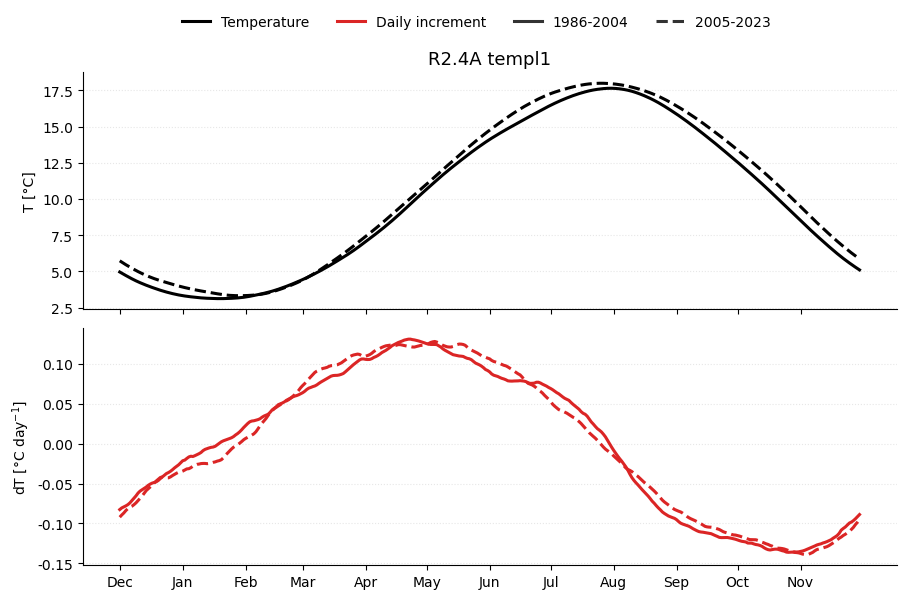

In [ ]:
# fig, (ax1, ax2) = plt.subplots(
#     2, 1, figsize=(10.5, 6.4), sharex=True,
#     gridspec_kw={'hspace': 0.08}
# )

# temp_color = 'black'
# tend_color = COLORS[1]

# ax1.plot(x, temp_old, color=temp_color, lw=2.2, ls='-')
# ax1.plot(x, temp_new, color=temp_color, lw=2.2, ls='--')

# ax2.plot(x, tend_old, color=tend_color, lw=2.2, ls='-')
# ax2.plot(x, tend_new, color=tend_color, lw=2.2, ls='--')

# for ax in [ax1, ax2]:
#     ax.grid(axis='y', linestyle=':', alpha=0.3)
#     ax.set_axisbelow(True)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)

# ax2.set_xticks(month_ticks)
# ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# ax1.set_ylabel('T [°C]')
# ax2.set_ylabel('dT [°C day$^{-1}$]')

# ax1.set_title('R2.4A templ1', fontsize=13)

# fig.legend(
#     handles=[
#         Line2D([0], [0], color=temp_color, lw=2.2, label='Temperature'),
#         Line2D([0], [0], color=tend_color, lw=2.2, label='Daily increment'),
#         Line2D([0], [0], color='0.2', lw=2.2, ls='-', label=period_label('PtrendL')),
#         Line2D([0], [0], color='0.2', lw=2.2, ls='--', label=period_label('PtrendR')),
#     ],
#     loc='upper center',
#     bbox_to_anchor=(0.5, 0.99),
#     ncol=4,
#     frameon=False,
# )

# plt.tight_layout(rect=[0, 0, 1, 0.94])
# plt.show()

/tmp/ipykernel_1255768/1898868446.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


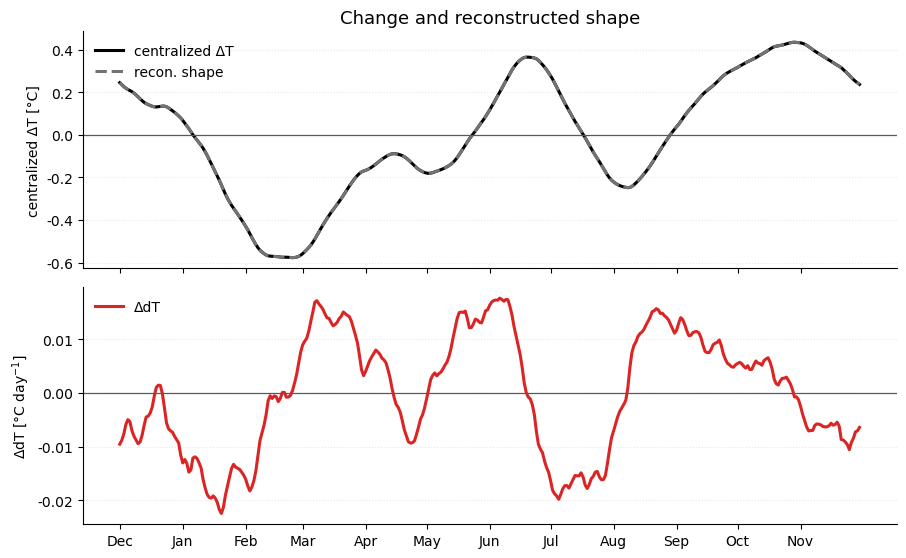

In [ ]:
# fig, (ax1, ax2) = plt.subplots(
#     2, 1, figsize=(10.5, 6.4), sharex=True,
#     gridspec_kw={'hspace': 0.08}
# )

# shape_color = '0.45'
# tend_color = COLORS[1]

# ax1.plot(x, deltaT_c, color='black', lw=2.2, label='centralized ΔT')
# ax1.plot(x, Trec_c, color=shape_color, lw=2.2, ls='--', label='recon. shape')

# ax2.plot(x, deltadT, color=tend_color, lw=2.2, label='ΔdT')

# for ax in [ax1, ax2]:
#     ax.grid(axis='y', linestyle=':', alpha=0.3)
#     ax.set_axisbelow(True)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.axhline(0, color='0.35', lw=0.9)

# ax2.set_xticks(month_ticks)
# ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# ax1.set_ylabel('centralized ΔT [°C]')
# ax2.set_ylabel('ΔdT [°C day$^{-1}$]')

# ax1.set_title('Change and reconstructed shape', fontsize=13)

# ax1.legend(loc='upper left', frameon=False)
# ax2.legend(loc='upper left', frameon=False)

# plt.tight_layout()
# plt.show()

/tmp/ipykernel_1255768/1629085216.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.92])


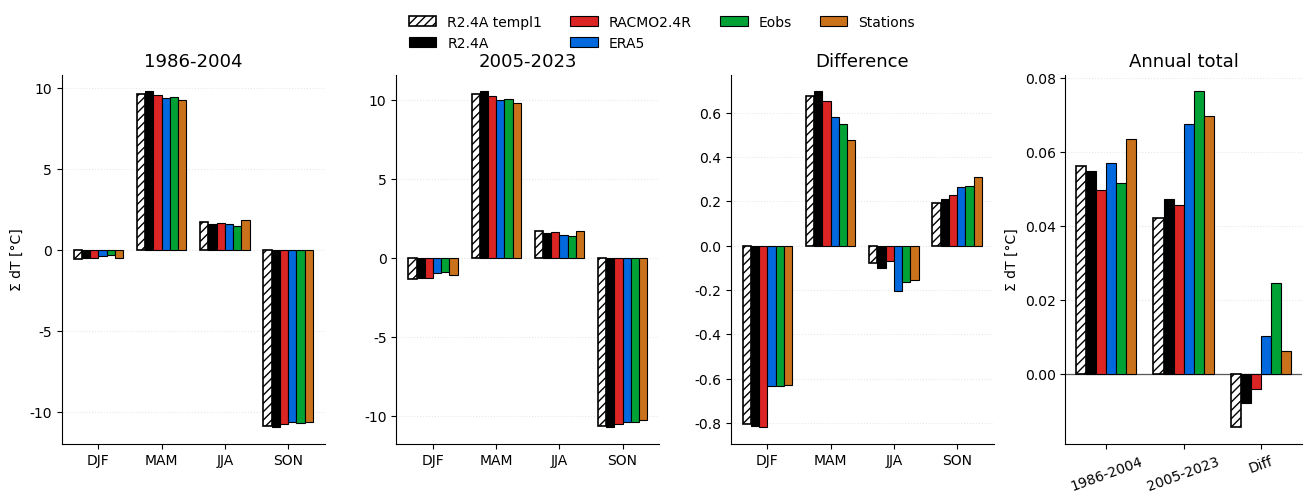

In [ ]:
# fig, axes = plt.subplots(
#     1, 4, figsize=(16, 4.8),
#     gridspec_kw={'width_ratios': [1, 1, 1, 0.9], 'wspace': 0.28}
# )

# width = 0.78 / len(series)
# x_season = np.arange(len(season_order))
# x_all = np.arange(3)

# panel_keys = ['PtrendL', 'PtrendR', 'Diff']
# panel_titles = [period_label('PtrendL'), period_label('PtrendR'), 'Difference']

# for ax, key, title in zip(axes[:3], panel_keys, panel_titles):
#     for i, s in enumerate(series):
#         offset = (i - (len(series) - 1) / 2) * width
#         vals = seasonal_total_tend[s['label']][key].values

#         ax.bar(
#             x_season + offset, vals, width=width,
#             color=s['facecolor'],
#             edgecolor=s['edgecolor'],
#             hatch=s['hatch'],
#             linewidth=s['linewidth'],
#             zorder=3,
#         )

#     ax.set_xticks(x_season)
#     ax.set_xticklabels(season_order)
#     ax.set_title(title, fontsize=13)
#     ax.grid(axis='y', linestyle=':', alpha=0.3)
#     ax.set_axisbelow(True)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)

# for i, s in enumerate(series):
#     offset = (i - (len(series) - 1) / 2) * width
#     vals = [
#         annual_total_tend[s['label']]['PtrendL'].item(),
#         annual_total_tend[s['label']]['PtrendR'].item(),
#         annual_total_tend[s['label']]['Diff'].item(),
#     ]

#     axes[3].bar(
#         x_all + offset, vals, width=width,
#         color=s['facecolor'],
#         edgecolor=s['edgecolor'],
#         hatch=s['hatch'],
#         linewidth=s['linewidth'],
#         zorder=3,
#     )

# axes[3].set_xticks(x_all)
# axes[3].set_xticklabels([period_label('PtrendL'), period_label('PtrendR'), 'Diff'], rotation=20)
# axes[3].set_title('Annual total', fontsize=13)
# axes[3].grid(axis='y', linestyle=':', alpha=0.3)
# axes[3].set_axisbelow(True)
# axes[3].spines['top'].set_visible(False)
# axes[3].spines['right'].set_visible(False)
# axes[3].axhline(0, color='0.35', lw=0.9)

# axes[0].set_ylabel('Σ dT [°C]')
# axes[3].set_ylabel('Σ dT [°C]')

# fig.legend(
#     handles=bar_handles,
#     loc='upper center',
#     bbox_to_anchor=(0.5, 1.03),
#     ncol=min(len(bar_handles), 4),
#     frameon=False,
# )

# plt.tight_layout(rect=[0, 0, 1, 0.92])
# plt.show()

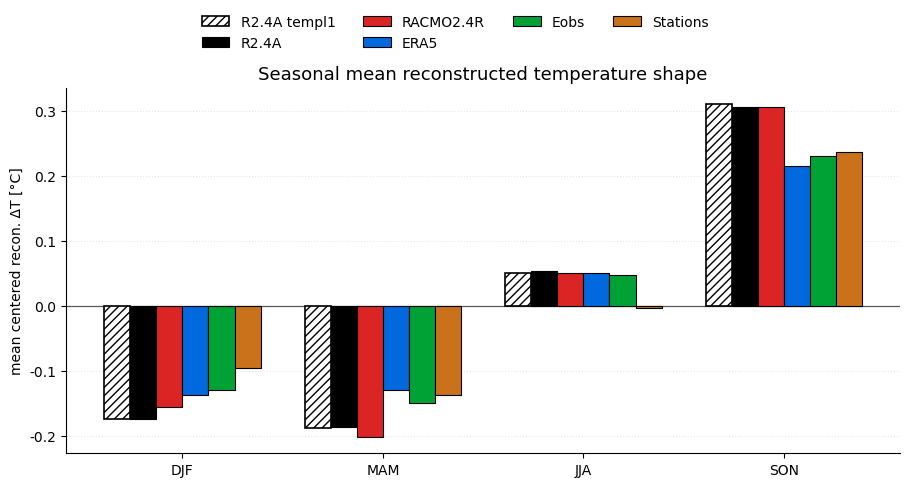

In [ ]:
# fig, ax = plt.subplots(figsize=(9.2, 4.8))

# width = 0.78 / len(series)
# x = np.arange(len(season_order))

# for i, s in enumerate(series):
#     offset = (i - (len(series) - 1) / 2) * width
#     vals = seasonal_recon_shape[s['label']].values

#     ax.bar(
#         x + offset, vals, width=width,
#         color=s['facecolor'],
#         edgecolor=s['edgecolor'],
#         hatch=s['hatch'],
#         linewidth=s['linewidth'],
#         zorder=3,
#     )

# ax.set_xticks(x)
# ax.set_xticklabels(season_order)
# ax.set_ylabel('mean centered recon. ΔT [°C]')
# ax.set_title('Seasonal mean reconstructed temperature shape', fontsize=13)
# ax.grid(axis='y', linestyle=':', alpha=0.3)
# ax.set_axisbelow(True)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.axhline(0, color='0.35', lw=0.9)

# fig.legend(
#     handles=bar_handles,
#     loc='upper center',
#     bbox_to_anchor=(0.5, 1.02),
#     ncol=min(len(bar_handles), 4),
#     frameon=False,
# )

# plt.tight_layout(rect=[0, 0, 1, 0.92])
# plt.show()

In [ ]:
# # Figure 1
# datasets = [ds for ds in clim_temp if 'Tg' in clim_temp[ds]]

# series = []

# if 'RACMO2.4A' in clim_temp and 'templ1' in clim_temp['RACMO2.4A']:
#     series.append({
#         'dataset': 'RACMO2.4A',
#         'var': 'templ1',
#         'label': 'R2.4A layer',
#     })

# for ds in datasets:
#     series.append({
#         'dataset': ds,
#         'var': 'Tg',
#         'label': name_map.get(ds, ds),
#     })

# for i, s in enumerate(series):
#     s['color'] = COLORS[i % len(COLORS)]
#     s['edgecolor'] = 'black'
#     s['linewidth'] = 0.8

# handles = [
#     Patch(
#         facecolor=s['color'],
#         edgecolor=s['edgecolor'],
#         linewidth=s['linewidth'],
#         label=s['label'],
#     )
#     for s in series
# ]

# for left_key, right_key in [('PrefL', 'PrefR'), ('PtrendL', 'PtrendR')]:
#     seasonal = {}

#     for s in series:
#         ds, var = s['dataset'], s['var']

#         left_season = aggregate_calendar(
#             clim_temp[ds][var][left_key],
#             split='season',
#             how='mean',
#         )

#         right_season = aggregate_calendar(
#             clim_temp[ds][var][right_key],
#             split='season',
#             how='mean',
#         )

#         left_all = xr.DataArray(
#             [clim_temp[ds][var][left_key].mean('month_day').astype('float32').item()],
#             dims='season',
#             coords={'season': ['ALL']},
#         )

#         right_all = xr.DataArray(
#             [clim_temp[ds][var][right_key].mean('month_day').astype('float32').item()],
#             dims='season',
#             coords={'season': ['ALL']},
#         )

#         left = xr.concat([left_season, left_all], dim='season').sel(season=season_order)
#         right = xr.concat([right_season, right_all], dim='season').sel(season=season_order)

#         seasonal[s['label']] = {
#             left_key: left,
#             right_key: right,
#             'Diff': (right - left).astype('float32'),
#         }

#     fig, axes = plt.subplots(1, 3, figsize=(15.2, 5.2))
#     fig.subplots_adjust(top=0.83, wspace=0.30)

#     x = np.arange(len(season_order))
#     width = 0.72 / len(series)

#     panel_keys = [left_key, right_key, 'Diff']
#     panel_titles = [
#         period_label(left_key),
#         period_label(right_key),
#         'Period change',
#     ]

#     diff_vals = np.concatenate([
#         seasonal[s['label']]['Diff'].values for s in series
#     ])

#     diff_range = diff_vals.max() - diff_vals.min()
#     diff_pad = 0.08 * max(diff_range, 1e-6)

#     for ax, key, title in zip(axes, panel_keys, panel_titles):
#         for i, s in enumerate(series):
#             offset = (i - (len(series) - 1) / 2) * width
#             vals = seasonal[s['label']][key].values

#             ax.bar(
#                 x + offset,
#                 vals,
#                 width=width,
#                 color=s['color'],
#                 edgecolor=s['edgecolor'],
#                 linewidth=s['linewidth'],
#                 zorder=3,
#             )

#         ax.set_xticks(x)
#         ax.set_xticklabels(season_order)
#         ax.set_title(title, fontsize=12)
#         ax.grid(axis='y', linestyle=':', alpha=0.3)
#         ax.set_axisbelow(True)
#         ax.spines['top'].set_visible(False)
#         ax.spines['right'].set_visible(False)

#     axes[0].set_ylabel('Temperature $T$ (°C)')
#     axes[1].set_ylabel('Temperature $T$ (°C)')
#     axes[2].set_ylabel('Temperature change $\\Delta T$ (°C)')

#     axes[0].set_ylim(0, 18)
#     axes[1].set_ylim(0, 18)

#     if diff_vals.min() >= 0:
#         axes[2].set_ylim(0, diff_vals.max() + diff_pad)
#     elif diff_vals.max() <= 0:
#         axes[2].set_ylim(diff_vals.min() - diff_pad, 0)
#     else:
#         axes[2].set_ylim(diff_vals.min() - diff_pad, diff_vals.max() + diff_pad)

#     axes[2].axhline(0, color='0.35', lw=0.9)

#     L = float(weights_kappa(periods[left_key], periods[right_key]).sum('year').item())

#     secax = axes[2].secondary_yaxis(
#         'right',
#         functions=(
#             lambda y: y * 10.0 / L,
#             lambda y: y * L / 10.0,
#         ),
#     )
#     secax.set_ylabel('Trend (°C / decade)')

#     fig.legend(
#         handles=handles,
#         loc='upper center',
#         bbox_to_anchor=(0.5, 0.98),
#         ncol=len(handles),
#         frameon=False,
#     )

#     plt.show()